# 05 · CUB70 CBM exploration — what does each named concept use?

This notebook studies **CBMs only**. It does not use MCBM and it does not use
visibility-relabelled training.

We also do not assume CUB must repeat FunnyBirds. FunnyBirds gives us careful
questions to ask. CUB70 is allowed to answer differently.

The order is fixed:

1. list the dataset objects;
2. count species and concepts;
3. count visibility for all 11 masks;
4. describe label/species structure;
5. check that the CBM works normally;
6. inspect visibility behavior at the full attribute-type and exact-concept
   levels;
7. investigate any odd result;
8. only at the end compare the CUB70-trained CBM with the full-CUB-trained CBM.

Every plot begins with a question and a decision rule. Literal observations are
added only after the executed image is displayed and inspected.


## 0 · The complete non-RL reasoning inherited from FunnyBirds

The standard CBM notebook first checked training and untouched images. It then
deleted one part, validated a one-part swap visually, compared the inserted and
old concept scores, checked both directions and coverage, separated visual
response from final victory, tested visibility, tested exact variants, and only
then asked whether source body/species still mattered. Species decoding and task
effects were kept separate from grounding.

The standard MCBM notebook came next. It first verified that `gamma` really
compressed the representation, then repeated the same swap, visibility,
deletion, variant, direction, seed, and species controls. Its central lesson was
simple: a small bottleneck can still read the wrong pixels. Relabeling was only a
later proposed cause test; it is not part of either discovery notebook.

The full minute-by-minute chain is frozen in
`CUB70_CBM_EXPLORATION_PLAN.md`.


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURATED = Path(os.environ["CURATED_DATA"])
CWD = Path.cwd()
REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
sys.path.insert(0, str(REPO/"analysis"))
sys.path.insert(0, str(REPO/"data"/"cub70"))

from cub70_parts import (
    CUB70_PARTS, COARSE_TO_CUB70, ATTRIBUTE_TYPE_TO_MASK, attribute_type,
)
from relabel_cub_with_cub70 import coarse_visibility

COLORS = {
    "beak":"#E69F00", "eye":"#CC79A7", "head":"#56B4E9",
    "neck":"#009E73", "body":"#0072B2", "wing":"#D55E00",
    "leg":"#999999", "tail":"#F0E442", None:"#333333",
}

def require(path, command):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}\nProduce it with: {command}")
    return path

def family(name):
    return str(name).split("::", 1)[0]

def add_mapping(E):
    E = E.copy()
    E["attribute_type"] = E.concept_name.map(family)
    E["mask_group"] = E.attribute_type.map(ATTRIBUTE_TYPE_TO_MASK)
    return E

def attach(E, coarse):
    E = add_mapping(E)
    local = E[E.mask_group.notna()].copy()
    V = coarse.rename(columns={"image_name":"image", "coarse":"mask_group"})
    return local.merge(V[["image","mask_group","pixel_count","area_frac","visible"]],
                       on=["image","mask_group"], how="inner")

def exact_visibility_metrics(J):
    rows=[]
    for (ctype,cname),d in J[J.gt_label==1].groupby(["attribute_type","concept_name"]):
        vis=d[d.visible].prob; hid=d[~d.visible].prob
        rows.append({
            "attribute_type":ctype,"concept_name":cname,"mask_group":d.mask_group.iloc[0],
            "n_positive":len(d),"n_visible":len(vis),"n_hidden":len(hid),
            "label_hidden_rate":len(hid)/len(d),
            "prob_visible":vis.mean() if len(vis) else np.nan,
            "prob_hidden":hid.mean() if len(hid) else np.nan,
            "visibility_effect":vis.mean()-hid.mean() if len(vis) and len(hid) else np.nan,
            "visible_recall":(vis>=.5).mean() if len(vis) else np.nan,
            "hidden_violation":(hid>=.5).mean() if len(hid) else np.nan,
            "prob_std":d.prob.std(),"unique_prob_6dp":d.prob.round(6).nunique(),
        })
    return pd.DataFrame(rows)

def matched_effects(J):
    P=J[J.gt_label==1]
    g=(P.groupby(["attribute_type","concept_name","y_true","visible"]).prob.mean()
       .unstack("visible"))
    if not {False,True}.issubset(g.columns): return pd.DataFrame()
    g=g.dropna(subset=[False,True]).copy()
    g["effect"]=g[True]-g[False]
    return g.reset_index()

def task_and_concept_accuracy(E):
    images=E[["image","y_true","y_pred"]].drop_duplicates("image")
    return pd.DataFrame([{
        "n_images":len(images), "n_species":images.y_true.nunique(),
        "task_accuracy":(images.y_true==images.y_pred).mean(),
        "concept_accuracy":(E.gt_label==E.pred_label).mean(),
    }])

def bilateral_features(raw):
    # Keep left/right evidence without inventing lateralized concepts.
    rows=[]
    pairs={
        "eye":("left_eye","right_eye"),
        "wing":("left_wing","right_wing"),
        "leg":("left_leg","right_leg"),
    }
    for group,(left,right) in pairs.items():
        d=raw[raw.part.isin([left,right])]
        area=d.pivot(index="image_name",columns="part",values="area_frac").fillna(0)
        vis=d.pivot(index="image_name",columns="part",values="visible").fillna(False)
        for image in area.index:
            lv=bool(vis.loc[image].get(left,False));rv=bool(vis.loc[image].get(right,False))
            if lv and rv: state="both"
            elif lv: state="left_only"
            elif rv: state="right_only"
            else: state="none"
            la=float(area.loc[image].get(left,0));ra=float(area.loc[image].get(right,0))
            rows.append({
                "image":image,"mask_group":group,"visible_sides":int(lv)+int(rv),
                "side_state":state,"left_area":la,"right_area":ra,
                "bilateral_total_area":la+ra,"largest_side_area":max(la,ra),
            })
    return pd.DataFrame(rows)

SEED=1
VIS_PATH=require(CURATED/"cub70_visibility.parquet", "bash data/cub70/prepare_all.sh")
E70_PATH=require(CURATED/"cub70_eval"/f"cub70-cbm-s{SEED}.parquet",
                 "CONFIGS='cub70-cbm' SEEDS='1' bash analysis/cub70_prepare_analysis.sh")
EFULL_PATH=require(CURATED/"cub70_eval"/f"cub-cbm-s{SEED}.parquet",
                   "CONFIGS='cub-cbm' SEEDS='1' bash analysis/cub70_prepare_analysis.sh")
RAWVIS=pd.read_parquet(VIS_PATH)
COARSE=coarse_visibility(RAWVIS, threshold=.001)
BILATERAL=bilateral_features(RAWVIS)
E70=add_mapping(pd.read_parquet(E70_PATH))
EFULL=add_mapping(pd.read_parquet(EFULL_PATH))
J70=attach(E70,COARSE).merge(BILATERAL,on=["image","mask_group"],how="left")
JFULL=attach(EFULL,COARSE).merge(BILATERAL,on=["image","mask_group"],how="left")
print("ready:",len(E70),"CUB70-CBM concept rows;",RAWVIS.image_name.nunique(),"masked images")


ready: 221312 CUB70-CBM concept rows; 1888 masked images


## 1 · What concepts and masks actually exist?

**Question.** What are we measuring before anything is pooled?

**Variables.** CUB concept names have an attribute type before `::` and a value
after it. CUB70 separately supplies 11 masks.

**Decision rule.** Print every type, its selected values, and its mask. Whole-bird
size and shape have no valid local mask and are excluded from local grounding.
The five body-region types are kept distinct even though the released data gives
them the same body mask.


,attribute_type,mask_group,n_selected_concepts,selected_values
0,has_back_color,body,6,"black, brown, buff, grey, white, yellow"
1,has_back_pattern,body,3,"multi-colored, solid, striped"
2,has_belly_color,body,6,"black, brown, buff, grey, white, yellow"
3,has_belly_pattern,body,1,solid
4,has_bill_color,beak,3,"black, buff, grey"
5,has_bill_length,beak,2,"about_the_same_as_head, shorter_than_head"
6,has_bill_shape,beak,4,"all-purpose, cone, dagger, hooked_seabird"
7,has_breast_color,body,6,"black, brown, buff, grey, white, yellow"
8,has_breast_pattern,body,3,"multi-colored, solid, striped"
9,has_crown_color,head,6,"black, blue, brown, grey, white, yellow"


attribute types: 28
selected concept values: 112
fine masks: 11 ['head', 'right_eye', 'left_eye', 'beak', 'neck', 'body', 'right_wing', 'left_wing', 'right_leg', 'left_leg', 'tail']


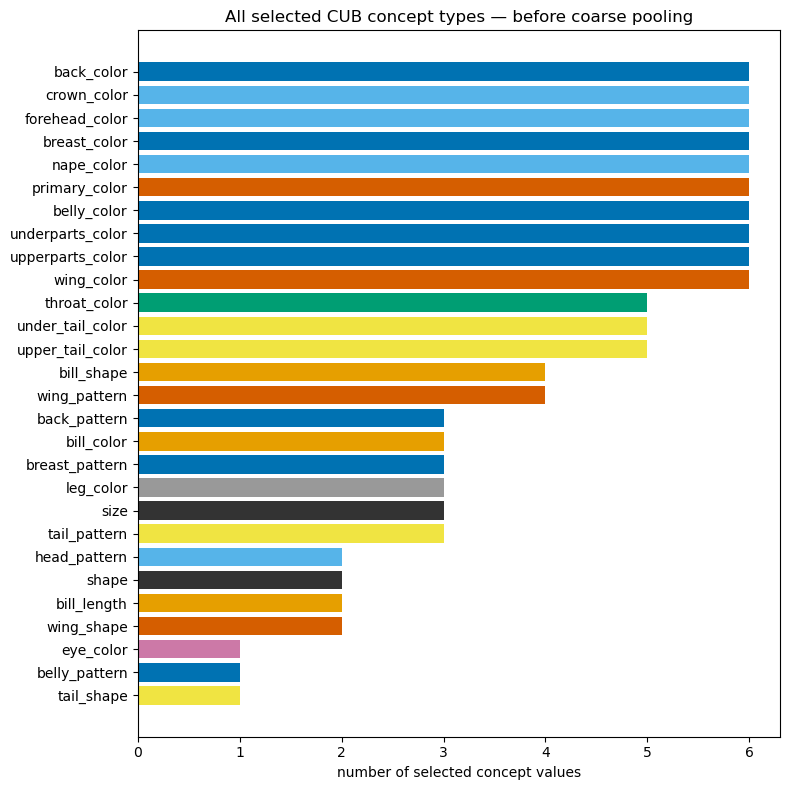

In [2]:
concepts=(E70[["concept_name","attribute_type","mask_group"]].drop_duplicates()
          .sort_values(["attribute_type","concept_name"]))
inventory=(concepts.groupby(["attribute_type","mask_group"],dropna=False)
           .agg(n_selected_concepts=("concept_name","size"),
                selected_values=("concept_name",lambda s:", ".join(x.split("::",1)[1] for x in s)))
           .reset_index())
display(inventory)
print("attribute types:",inventory.attribute_type.nunique())
print("selected concept values:",len(concepts))
print("fine masks:",len(CUB70_PARTS),CUB70_PARTS)

fig,ax=plt.subplots(figsize=(8,8))
q=inventory.sort_values("n_selected_concepts")
ax.barh(q.attribute_type.str.replace("has_","",regex=False),q.n_selected_concepts,
        color=[COLORS.get(x,"#333333") for x in q.mask_group])
ax.set_xlabel("number of selected concept values")
ax.set_title("All selected CUB concept types — before coarse pooling")
plt.tight_layout();plt.show()


### What Figure 1 says

**Literal observation.** The model has 112 selected concept values spread across
all 28 CUB attribute types. Twenty-six types can be linked to a released mask.
The five individual values belonging to whole-bird `size` and `shape` cannot be
given an honest local mask, so 107 exact concepts remain for local analysis.

Breast, belly, back, upperparts, and underparts remain separate concept types,
even though all five must use the same coarse body mask. Eye, wing, and leg
concepts are not left/right concepts, even though their masks are lateralized.

**Alternative explanation to guard against.** Pooling all body concepts or all
wing concepts now would hide real differences between color, pattern, and shape.

**Limited conclusion.** CUB must be analysed first at exact-concept and
28-type resolution. The available mask is recorded as a limitation, not treated
as the definition of the concept.

**Next question.** Which species and photographs actually have masks?


## 2 · How many species and images are in this exact analysis?

**Question.** Is this a 200-species or 70-species result, and is coverage balanced?

**Prediction.** None. We print the population before model behavior so a later
part result cannot quietly be caused by using only a few species or images.


,population,n_images,n_species
0,all CUB70 test predictions,1976,70
1,images with CUB70 masks used below,1888,67


,min_masked_images_per_species,median_masked_images_per_species,max_masked_images_per_species
0,11,30.0,30


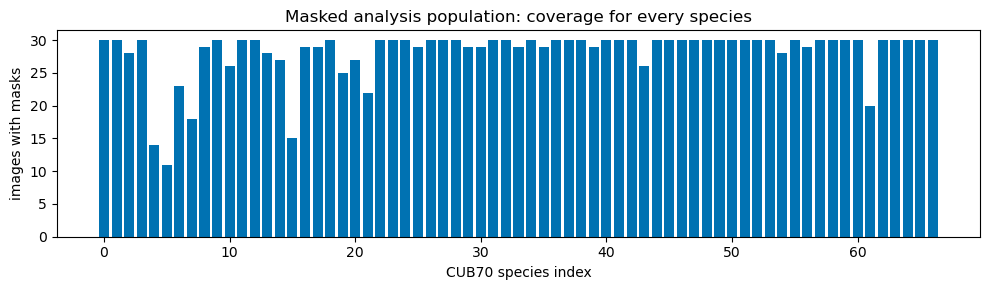

In [3]:
all_images=E70[["image","y_true"]].drop_duplicates()
masked_images=J70[["image","y_true"]].drop_duplicates()
coverage=pd.DataFrame([
    {"population":"all CUB70 test predictions","n_images":len(all_images),
     "n_species":all_images.y_true.nunique()},
    {"population":"images with CUB70 masks used below","n_images":len(masked_images),
     "n_species":masked_images.y_true.nunique()},
])
display(coverage)
species_counts=masked_images.groupby("y_true").size().rename("n_images")
display(pd.DataFrame({
    "min_masked_images_per_species":[species_counts.min()],
    "median_masked_images_per_species":[species_counts.median()],
    "max_masked_images_per_species":[species_counts.max()],
}))
fig,ax=plt.subplots(figsize=(10,3))
ax.bar(range(len(species_counts)),species_counts.values,color="#0072B2")
ax.set_xlabel("CUB70 species index");ax.set_ylabel("images with masks")
ax.set_title("Masked analysis population: coverage for every species")
plt.tight_layout();plt.show()


### What Figure 2 says

**Literal observation.** The CUB70 prediction export contains 1,976 photographs
from 70 species. Only 1,888 photographs join to the released masks, and those
photographs cover 67 model species. Covered species contribute 11–30 images,
with a median of 30.

**Odd result.** Three predicted species disappear completely after the mask
join. This may be an archive-coverage or filename-alignment issue; it is not a
model result.

**Limited conclusion.** Every visibility result below describes the 1,888-image,
67-species masked population, not the complete 70-species prediction set.

**Next question.** Within that population, which fine masks are usually visible?
The missing-species identities must also be audited before claiming full CUB70
coverage.


## 3 · Visibility inventory for all 11 masks

**Question.** Which regions are commonly absent in these photographs?

**Variables.** `visible` means the fine mask covers at least 0.1% of the image.
For eyes, wings, and legs, we also count whether zero, one, or both sides are
visible. We do not yet use concept labels or predictions.

**Why this comes first.** A concept cannot be tested often under natural
occlusion if its mask is almost always visible. Left/right asymmetry can also be
lost by immediately merging the two sides.


,part,n_images,visible_rate,mean_area,median_area
0,head,1888,0.9931,0.0187,0.0141
1,right_eye,1888,0.2251,0.0006,0.0000
2,left_eye,1888,0.2346,0.0006,0.0001
3,beak,1888,0.9296,0.0041,0.0031
4,neck,1888,0.2230,0.0035,0.0000
5,body,1888,0.9783,0.0444,0.0351
6,right_wing,1888,0.5975,0.0228,0.0090
7,left_wing,1888,0.5980,0.0229,0.0093
8,right_leg,1888,0.6478,0.0034,0.0024
9,left_leg,1888,0.6462,0.0034,0.0024


,group,visible_sides,fraction_images,n
0,eye,0,0.5477,1034
1,eye,1,0.4449,840
2,eye,2,0.0074,14
3,wing,0,0.1552,293
4,wing,1,0.4942,933
5,wing,2,0.3506,662
6,leg,0,0.2548,481
7,leg,1,0.1965,371
8,leg,2,0.5487,1036


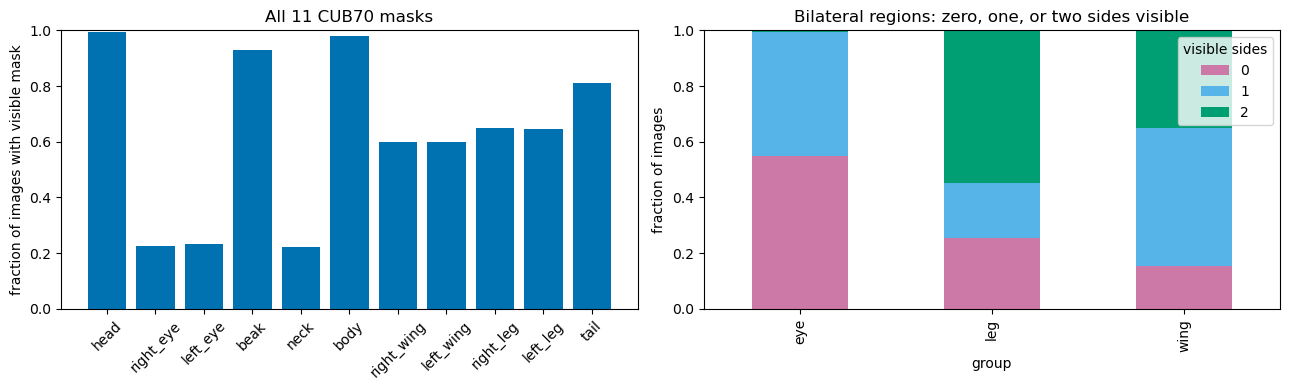

In [4]:
fine=(RAWVIS.groupby("part").agg(
    n_images=("image_name","nunique"), visible_rate=("visible","mean"),
    mean_area=("area_frac","mean"), median_area=("area_frac","median"),
).reindex(CUB70_PARTS).reset_index())
display(fine.round(4))

side_rows=[]
for group,parts in {"eye":["left_eye","right_eye"],
                    "wing":["left_wing","right_wing"],
                    "leg":["left_leg","right_leg"]}.items():
    d=RAWVIS[RAWVIS.part.isin(parts)].pivot(index="image_name",columns="part",values="visible")
    n=d.fillna(False).sum(axis=1).astype(int)
    for k,v in n.value_counts(normalize=True).sort_index().items():
        side_rows.append({"group":group,"visible_sides":k,"fraction_images":v,"n":(n==k).sum()})
SIDES=pd.DataFrame(side_rows)
display(SIDES.round(4))

fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].bar(fine.part,fine.visible_rate,color="#0072B2")
axes[0].set_ylim(0,1);axes[0].tick_params(axis="x",rotation=45)
axes[0].set_ylabel("fraction of images with visible mask")
axes[0].set_title("All 11 CUB70 masks")
S=SIDES.pivot(index="group",columns="visible_sides",values="fraction_images").fillna(0)
S.plot.bar(stacked=True,ax=axes[1],color=["#CC79A7","#56B4E9","#009E73"])
axes[1].set_ylim(0,1);axes[1].set_ylabel("fraction of images")
axes[1].set_title("Bilateral regions: zero, one, or two sides visible")
axes[1].legend(title="visible sides")
plt.tight_layout();plt.show()


### What Figure 3 says

**Literal observation.** Head (99.3%), body (97.8%), and beak (93.0%) are almost
always visible. Tail is visible in 81.1% of photographs. Each wing is visible in
about 59.8%, and each leg in about 64.7%. Each eye and the neck are visible in
only about 22–23%.

For bilateral regions, neither eye is visible in 54.8% of photographs and both
eyes are visible in only 14 photographs. Wings have useful zero/one/two-side
variation (15.5%/49.4%/35.1%). Legs most often show both sides (54.9%).

**Alternative explanation.** A missing mask can mean occlusion, viewpoint, or an
annotation limitation. Mask area is also not identical to diagnostic color or
pattern evidence.

**Limited conclusion.** Natural visibility provides a strong test opportunity
for eye and neck, a moderate opportunity for wing/leg/tail, and very little
hidden-case evidence for head/body/beak.

**Next question.** Before looking at predictions, how strongly does each exact
concept already identify a subset of species?


## 4 · Concept structure before model behavior

**Question.** How tightly is each concept tied to species identity?

**Variables.** For every exact concept, count the number of CUB70 species whose
processed label is positive. A concept positive in very few species gives a
stronger species clue than one shared by most species.

**Decision rule.** This does not prove that the model uses species pixels. It
only measures how easy a species shortcut would be.


,n_concepts,minimum,median,maximum
attribute_type,,,,
has_back_color,6,2,9.0,23
has_back_pattern,3,4,5.0,41
has_belly_color,6,3,7.0,22
has_belly_pattern,1,53,53.0,53
has_bill_color,3,1,4.0,34
has_bill_length,2,28,32.5,37
has_bill_shape,4,1,14.0,20
has_breast_color,6,4,5.0,22
has_breast_pattern,3,1,4.0,52


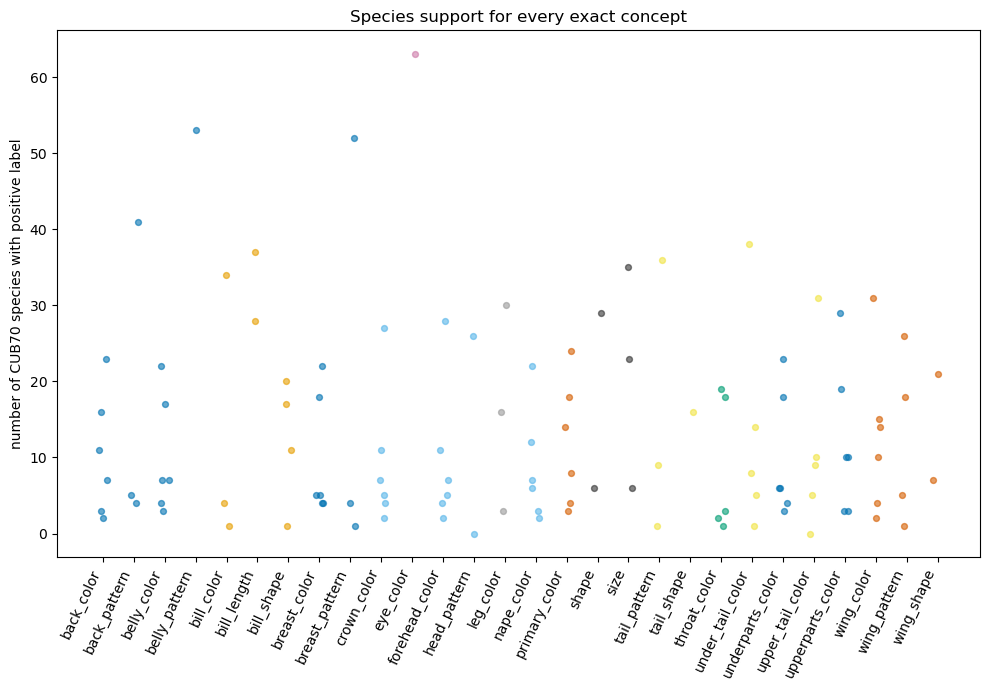

In [5]:
species_concept=(E70.groupby(["attribute_type","concept_name","y_true"]).gt_label.mean()
                 .reset_index())
support=(species_concept.assign(pos=lambda d:d.gt_label>=.5)
         .groupby(["attribute_type","concept_name"]).pos.sum()
         .rename("n_positive_species").reset_index())
display(support.groupby("attribute_type").n_positive_species.agg(
    n_concepts="size",minimum="min",median="median",maximum="max").round(2))

types=sorted(support.attribute_type.unique())
fig,ax=plt.subplots(figsize=(10,7))
rng=np.random.default_rng(20260731)
for i,t in enumerate(types):
    v=support.loc[support.attribute_type==t,"n_positive_species"]
    mask=ATTRIBUTE_TYPE_TO_MASK.get(t)
    ax.scatter(i+rng.uniform(-.15,.15,len(v)),v,s=18,alpha=.6,color=COLORS.get(mask,"#333333"))
ax.set_xticks(range(len(types)));ax.set_xticklabels([x.replace("has_","") for x in types],rotation=65,ha="right")
ax.set_ylabel("number of CUB70 species with positive label")
ax.set_title("Species support for every exact concept")
plt.tight_layout();plt.show()


### What Figure 4 says

**Literal observation.** Exact concepts vary from being positive in almost no
species to being positive in 63 of 70. Eye color is shared by 63 species, while
many color/pattern values occur in only a few species. This variation exists
across body, head, beak, tail, wing, and leg types.

**Why this is important.** A rare concept is a stronger clue to species identity
than a widely shared concept. That creates different shortcut opportunities for
different exact concepts, even inside the same anatomical region.

**Limited conclusion.** Species–concept structure is widespread and cannot be
summarized as a tail-only property. This graph does not prove that the model
reads species pixels.

**Next question.** When these species-linked labels are positive, how often is
the corresponding mask actually absent?


## 5 · Label/mask disagreement — still before model interpretation

**Question.** When a processed concept label is positive, how often is its named
mask absent?

This is not a relabel experiment. It is a count of the labels the existing CBM
was evaluated against.

**Prediction.** None. We calculate the rate separately for every exact concept.
A high rate creates more opportunity to learn a contextual shortcut, but it does
not prove the model took that shortcut.


,n_concepts,total_positive,median_hidden_rate,min_hidden_rate,max_hidden_rate
attribute_type,,,,,
has_throat_color,5,1192,0.715,0.698,0.966
has_eye_color,1,1720,0.514,0.514,0.514
has_leg_color,3,1312,0.319,0.205,0.462
has_under_tail_color,5,1803,0.222,0.181,0.867
has_upper_tail_color,4,1478,0.219,0.184,0.326
has_wing_pattern,4,1339,0.199,0.061,0.280
has_wing_shape,2,774,0.192,0.126,0.259
has_tail_pattern,3,1272,0.159,0.080,0.867
has_primary_color,6,1904,0.086,0.026,0.332


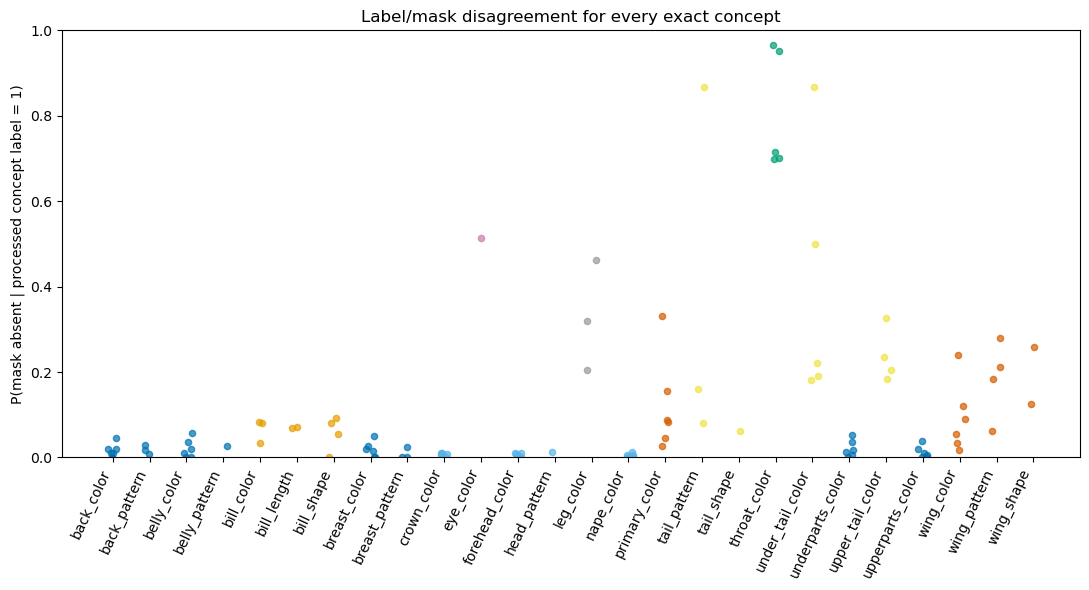

In [6]:
EXACT70=exact_visibility_metrics(J70)
display(EXACT70.groupby("attribute_type").agg(
    n_concepts=("concept_name","size"),
    total_positive=("n_positive","sum"),
    median_hidden_rate=("label_hidden_rate","median"),
    min_hidden_rate=("label_hidden_rate","min"),
    max_hidden_rate=("label_hidden_rate","max"),
).sort_values("median_hidden_rate",ascending=False).round(3))

types=sorted(EXACT70.attribute_type.unique())
fig,ax=plt.subplots(figsize=(11,6))
rng=np.random.default_rng(5)
for i,t in enumerate(types):
    d=EXACT70[EXACT70.attribute_type==t]
    ax.scatter(i+rng.uniform(-.14,.14,len(d)),d.label_hidden_rate,
               color=COLORS.get(d.mask_group.iloc[0],"#333333"),s=20,alpha=.7)
ax.set_xticks(range(len(types)));ax.set_xticklabels([x.replace("has_","") for x in types],rotation=65,ha="right")
ax.set_ylim(0,1);ax.set_ylabel("P(mask absent | processed concept label = 1)")
ax.set_title("Label/mask disagreement for every exact concept")
plt.tight_layout();plt.show()


### What Figure 5 says

**Literal observation.** Label/mask disagreement is largest for throat colors
(roughly 70–97%) and eye color (51%). Leg colors range roughly 21–46%.
Some individual tail concepts reach 87%, while other tail concepts are much
lower. Wing concepts range from near zero to roughly 33%. Most body, head, and
beak concepts have low disagreement because their masks are usually visible.

**Alternative explanation.** A coarse body or head mask cannot certify that the
smaller named region—belly, breast, crown, or nape—is visible. Low measured
disagreement for those types may therefore be falsely reassuring.

**Limited conclusion.** Visibility-conflicting supervision is a plausible risk
for throat, eye, leg, and selected tail/wing concepts. It is not uniformly a
tail problem, and this data count does not yet show what the model learned.

**Next question.** Did the CUB70-trained CBM learn usable, noncollapsed concept
outputs before visibility is interpreted?


## 6 · Did the CUB70-trained CBM work normally?

**Question.** Can this model support a grounding analysis at all?

**Variables.** Species accuracy, overall concept accuracy, positive-concept
recall, and prediction spread for every exact concept.

**Decision rule.** A concept with nearly constant probability is marked as a
collapsed output. A threshold below 0.5 is not evidence of grounding if the
model simply emits the same value for visible and hidden images.


,n_images,n_species,task_accuracy,concept_accuracy
0,1976,70,0.1412,0.7105


,n_concepts,median_accuracy,median_positive_recall,median_positive_std,minimum_unique_scores
attribute_type,,,,,
has_back_color,6,0.7353,0.7228,0.2246,34.0
has_back_pattern,3,0.6721,0.5189,0.2677,119.0
has_belly_color,6,0.7090,0.7969,0.2238,85.0
has_belly_pattern,1,0.5916,0.5426,0.2254,1302.0
has_bill_color,3,0.6184,0.7667,0.1680,9.0
has_bill_length,2,0.7176,0.7235,0.2456,812.0
has_bill_shape,4,0.6673,0.7152,0.2212,30.0
has_breast_color,6,0.6898,0.8123,0.2177,51.0
has_breast_pattern,3,0.8036,0.6167,0.2355,10.0


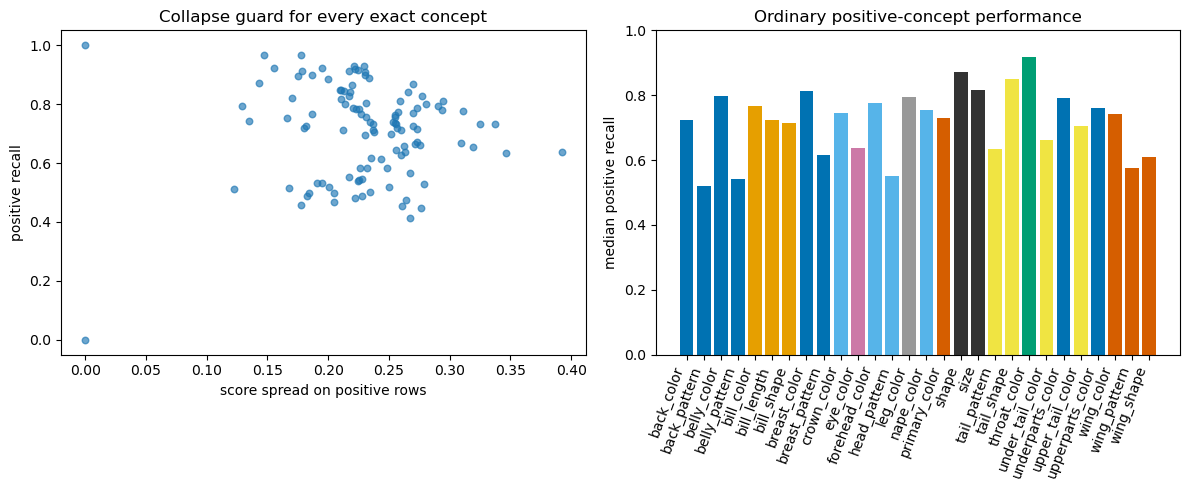

In [7]:
display(task_and_concept_accuracy(E70).round(4))
ordinary=(E70.groupby(["attribute_type","concept_name"]).agg(
    n=("prob","size"),prob_std=("prob","std"),
    concept_accuracy=("pred_label",lambda x:np.nan),
).reset_index())
acc=(E70.assign(correct=E70.pred_label==E70.gt_label)
     .groupby(["attribute_type","concept_name"]).correct.mean().rename("concept_accuracy").reset_index())
ordinary=ordinary.drop(columns="concept_accuracy").merge(acc)
pos=(E70[E70.gt_label==1].groupby(["attribute_type","concept_name"])
     .agg(positive_recall=("pred_label","mean"),positive_prob_mean=("prob","mean"),
          positive_prob_std=("prob","std"),unique_prob_6dp=("prob",lambda x:x.round(6).nunique()))
     .reset_index())
ordinary=ordinary.merge(pos,how="left")
display(ordinary.groupby("attribute_type").agg(
    n_concepts=("concept_name","size"),median_accuracy=("concept_accuracy","median"),
    median_positive_recall=("positive_recall","median"),
    median_positive_std=("positive_prob_std","median"),
    minimum_unique_scores=("unique_prob_6dp","min"),
).round(4))

fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(ordinary.positive_prob_std,ordinary.positive_recall,s=22,alpha=.65)
axes[0].set_xlabel("score spread on positive rows");axes[0].set_ylabel("positive recall")
axes[0].set_title("Collapse guard for every exact concept")
types=sorted(ordinary.attribute_type.unique())
med=ordinary.groupby("attribute_type").positive_recall.median().reindex(types)
axes[1].bar(range(len(types)),med,color=[COLORS.get(ATTRIBUTE_TYPE_TO_MASK.get(t),"#333333") for t in types])
axes[1].set_xticks(range(len(types)));axes[1].set_xticklabels([x.replace("has_","") for x in types],rotation=70,ha="right")
axes[1].set_ylim(0,1);axes[1].set_ylabel("median positive recall")
axes[1].set_title("Ordinary positive-concept performance")
plt.tight_layout();plt.show()


### What Figure 6 says

**Literal observation.** On its native 1,976-image test set, the CUB70-trained
CBM has 14.1% species accuracy and 71.1% overall concept accuracy. Median positive
recall varies substantially across attribute types. Most exact concepts show a
broad score distribution, but at least one throat-color output has only one
distinct rounded score and one wing-pattern output has only two.

**Odd result.** High or low thresholded recall can be produced by a nearly
constant score. Those collapsed exact concepts cannot count as grounded merely
because their score falls on one side of 0.5.

**Limited conclusion.** The model learned many nonconstant concepts, but it is a
weak classifier and contains some failed concept slots. Every later claim must
keep the collapse guard and ordinary performance visible.

**Next question.** For the non-global concepts, does seeing the available named
mask increase the prediction?


## 7 · First model question: does visibility change the named concept?

**Question.** For a processed positive concept, is its prediction higher when
the corresponding mask is visible than when it is absent?

**Decision rule.** Each line is one exact concept. Moving upward from hidden to
visible supports visual sensitivity. A flat high line means the concept stays
high without visible named-region evidence. A flat low line may instead be a
weak or collapsed concept and must be checked against Section 6.


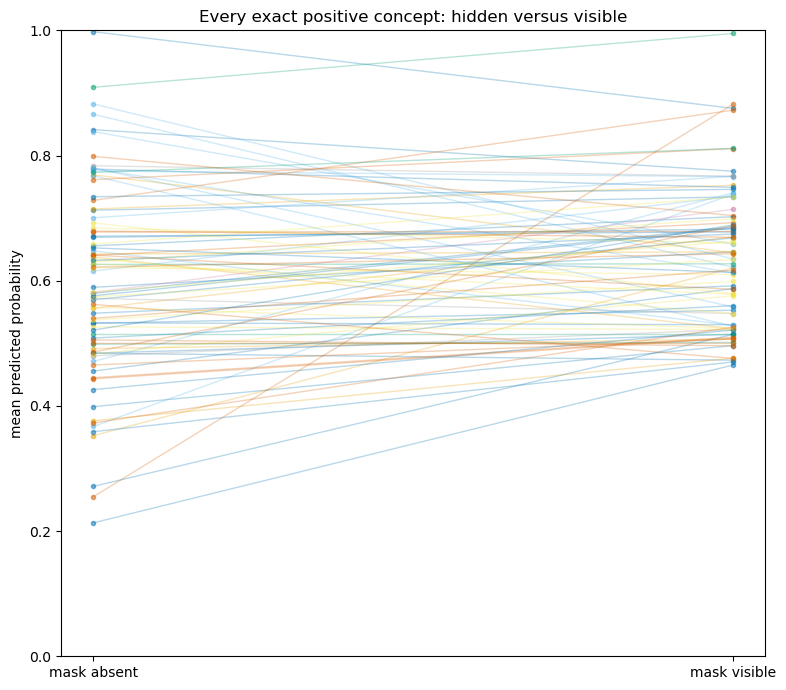

,n_testable,median_hidden_prob,median_visible_prob,median_visibility_effect
attribute_type,,,,
has_nape_color,3,0.7793,0.6584,-0.1667
has_crown_color,4,0.7714,0.6799,-0.1246
has_head_pattern,1,0.6477,0.5288,-0.1189
has_forehead_color,4,0.7403,0.6877,-0.0777
has_wing_pattern,4,0.6016,0.5430,-0.0706
has_bill_length,2,0.7059,0.6454,-0.0606
has_under_tail_color,5,0.5739,0.5989,-0.0240
has_leg_color,3,0.5718,0.5476,-0.0166
has_tail_pattern,3,0.6210,0.6097,-0.0043


In [8]:
T=(EXACT70.dropna(subset=["prob_visible","prob_hidden"])
   .sort_values(["attribute_type","concept_name"]).reset_index(drop=True))
fig,ax=plt.subplots(figsize=(8,7))
for r in T.itertuples():
    c=COLORS.get(r.mask_group,"#333333")
    ax.plot([0,1],[r.prob_hidden,r.prob_visible],color=c,alpha=.28,lw=1)
    ax.scatter([0,1],[r.prob_hidden,r.prob_visible],color=c,s=9,alpha=.5)
ax.set_xticks([0,1]);ax.set_xticklabels(["mask absent","mask visible"])
ax.set_ylim(0,1);ax.set_ylabel("mean predicted probability")
ax.set_title("Every exact positive concept: hidden versus visible")
plt.tight_layout();plt.show()

display(T.groupby("attribute_type").agg(
    n_testable=("concept_name","size"),median_hidden_prob=("prob_hidden","median"),
    median_visible_prob=("prob_visible","median"),
    median_visibility_effect=("visibility_effect","median"),
).sort_values("median_visibility_effect").round(4))


### What Figure 7 says

**Literal observation.** Exact concepts move in both directions. Eye color,
wing color, bill color, underparts color, and several body colors are higher on
visible photographs. Leg color and many tail measurements are nearly flat.
Wing pattern and several head-related types are lower when their mask is visible.

The head result is especially fragile because the head mask is absent in only
about 0.7% of photographs. It cannot carry the same weight as eye or wing results.

**Alternative explanations.** Visible and hidden groups can contain different
species and poses. Some exact concepts are weak or collapsed. One shared body
mask is also a poor local test for five smaller body regions.

**Limited conclusion.** CUB shows selective visual sensitivity, not one common
“part visibility” effect. A flat line does not prove occlusion was irrelevant:
training-time label conflict could have taught a contextual rule that is now
insensitive to test-time visibility.

**Next question.** Do concepts with more label/mask conflict show more hidden-part
model violations?


## 8 · Odd-result test A: label conflict versus model violation

**Question.** Are concepts that are often labelled positive while hidden also
the concepts most likely to stay predicted positive while hidden?

**Variables.** The x-axis is a data property. The y-axis is model behavior.
Point size shows how many species carry the positive concept.

**Decision rule.** A relationship would make label/mask conflict a plausible
explanation. No relationship would tell us to look elsewhere. Eight pooled
parts are not used; every point is an exact concept.


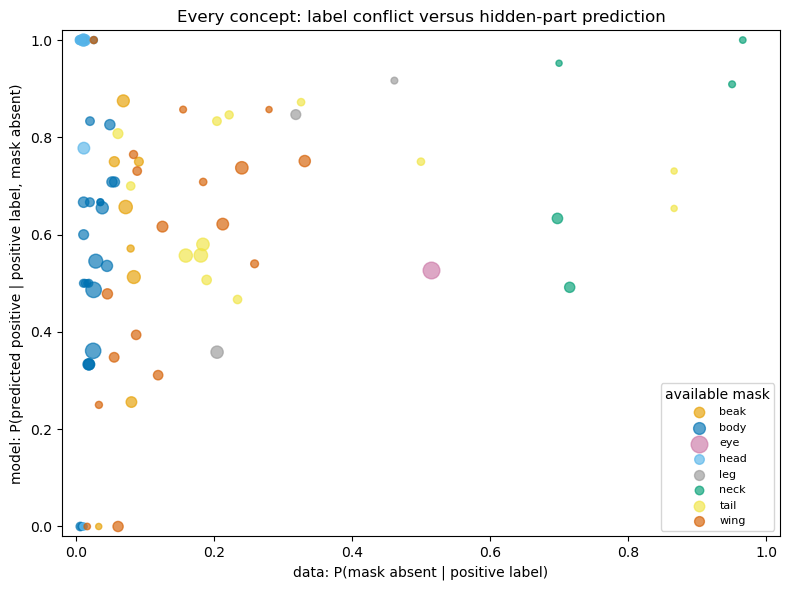

In [9]:
X=EXACT70.merge(support,on=["attribute_type","concept_name"],how="left")
fig,ax=plt.subplots(figsize=(8,6))
for mask,d in X.groupby("mask_group"):
    ax.scatter(d.label_hidden_rate,d.hidden_violation,
               s=18+2*d.n_positive_species,alpha=.65,label=mask,color=COLORS.get(mask))
ax.set_xlim(-.02,1.02);ax.set_ylim(-.02,1.02)
ax.set_xlabel("data: P(mask absent | positive label)")
ax.set_ylabel("model: P(predicted positive | positive label, mask absent)")
ax.set_title("Every concept: label conflict versus hidden-part prediction")
ax.legend(title="available mask",fontsize=8)
plt.tight_layout();plt.show()


### What Figure 8 says

**Literal observation.** There is no simple one-to-one pattern. Concepts with
little measured label conflict can still have high hidden-part prediction, and
high-conflict throat or tail concepts range from moderate to nearly complete
hidden prediction.

**Alternative explanation.** The y-axis uses a 0.5 threshold, so compressed or
collapsed scores can create extreme rates. Species support and mask quality also
differ across points.

**Limited conclusion.** Label/mask conflict remains a plausible cause, but it is
not sufficient by itself to explain which exact concepts remain positive while
hidden.

**Next question.** Ignoring the binary threshold, does a larger visible region
continuously strengthen the concept score?


## 9 · Odd-result test B: amount of visible area

**Question.** When the part is visible, does more mask area strengthen the exact
concept prediction?

**Decision rule.** For every concept with enough rows, compare its lowest and
highest area quartiles. Positive `Q4-Q1` supports an area response. Near zero
does not prove context use: mask area may be a poor measure for fine color or
pattern visibility.


,n_concepts,median,minimum,maximum
attribute_type,,,,
has_back_color,6,-0.0002,-0.0853,0.0674
has_back_pattern,3,0.0100,-0.0204,0.1729
has_belly_color,6,-0.0085,-0.1243,0.1600
has_belly_pattern,1,0.0294,0.0294,0.0294
has_bill_color,3,0.0436,-0.0223,0.1069
has_bill_length,2,-0.0630,-0.0997,-0.0264
has_bill_shape,4,-0.0222,-0.1630,0.0538
has_breast_color,6,-0.0036,-0.1194,0.1595
has_breast_pattern,2,0.0857,0.0208,0.1506


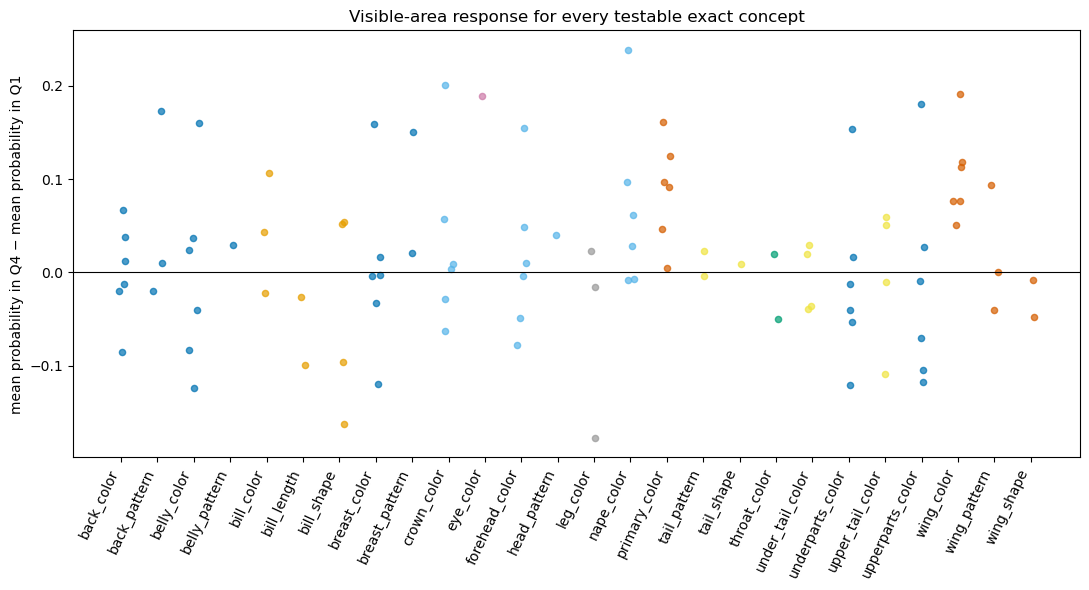

In [10]:
dose=[]
for (t,c),d in J70[(J70.gt_label==1)&(J70.area_frac>0)].groupby(["attribute_type","concept_name"]):
    if len(d)<20 or d.area_frac.nunique()<4: continue
    d=d.copy();d["q"]=pd.qcut(d.area_frac.rank(method="first"),4,labels=False)+1
    q=d.groupby("q").prob.mean()
    dose.append({"attribute_type":t,"concept_name":c,"n":len(d),"q4_minus_q1":q.get(4,np.nan)-q.get(1,np.nan)})
DOSE=pd.DataFrame(dose)
display(DOSE.groupby("attribute_type").q4_minus_q1.agg(n_concepts="size",median="median",minimum="min",maximum="max").round(4))
types=sorted(DOSE.attribute_type.unique())
fig,ax=plt.subplots(figsize=(11,6));rng=np.random.default_rng(9)
for i,t in enumerate(types):
    d=DOSE[DOSE.attribute_type==t]
    ax.scatter(i+rng.uniform(-.14,.14,len(d)),d.q4_minus_q1,s=20,alpha=.7,
               color=COLORS.get(ATTRIBUTE_TYPE_TO_MASK.get(t),"#333333"))
ax.axhline(0,color="black",lw=.8)
ax.set_xticks(range(len(types)));ax.set_xticklabels([x.replace("has_","") for x in types],rotation=65,ha="right")
ax.set_ylabel("mean probability in Q4 − mean probability in Q1")
ax.set_title("Visible-area response for every testable exact concept")
plt.tight_layout();plt.show()


### What Figure 9 says

**Literal observation.** Eye color, wing color, and primary-feather color tend
to rise from the smallest to largest visible-area quartile. Many body and head
concepts contain both positive and negative exact values. Wing shape, leg color,
and bill length do not show a consistent positive area response.

**Alternative explanation.** More pixels do not necessarily mean that the
diagnostic color, edge, or pattern is clearer. Area also changes with pose and
distance.

**Limited conclusion.** Visible area matters for selected concept types, not as
a universal grounding law.

**Next question.** For bilateral regions, can zero, one, and two visible sides
give a more direct visibility dose without inventing left/right concepts?


## 9b · Use the left/right masks without inventing left/right concepts

Eye, wing, primary-feather, and leg concepts are not labelled by side. We cannot
say that a score means “left wing color.” But the masks still provide useful
natural variation:

- zero visible sides;
- one visible side;
- both visible sides;
- total visible area;
- area of the larger visible side;
- left-only versus right-only photographs.

**Question.** Does a non-lateralized concept become stronger as more of its two
possible sides is visible?

**Decision rule.** A rise from zero to one to two sides supports visual
sensitivity. Left-only and right-only differences are reported as a pose/view
warning, not as evidence for a lateralized concept.


,mask_group,attribute_type,visible_sides,n,mean_probability
0,eye,has_eye_color,0.0,906,0.5824
1,eye,has_eye_color,1.0,800,0.7173
2,eye,has_eye_color,2.0,14,0.6576
3,leg,has_leg_color,0.0,348,0.5461
4,leg,has_leg_color,1.0,249,0.5315
5,leg,has_leg_color,2.0,715,0.5426
6,wing,has_primary_color,0.0,295,0.6382
7,wing,has_primary_color,1.0,881,0.6120
8,wing,has_primary_color,2.0,728,0.6146
9,wing,has_wing_color,0.0,297,0.6055


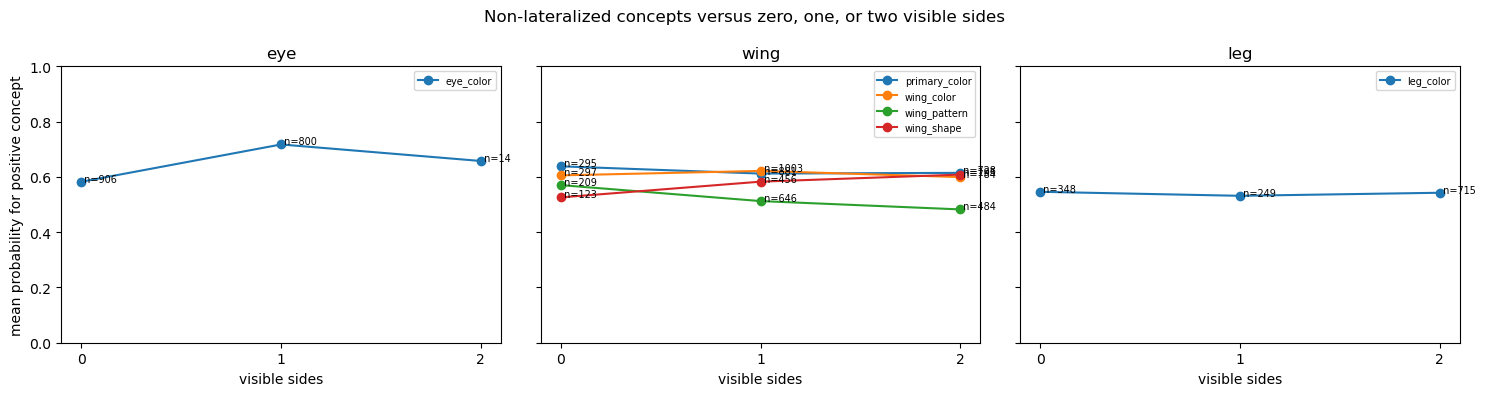

,attribute_type,side_state,n,mean_probability
0,has_eye_color,left_only,408,0.7246
1,has_eye_color,right_only,392,0.7097
2,has_leg_color,left_only,119,0.5252
3,has_leg_color,right_only,130,0.5373
4,has_primary_color,left_only,437,0.6271
5,has_primary_color,right_only,444,0.5971
6,has_wing_color,left_only,519,0.6447
7,has_wing_color,right_only,484,0.5969
8,has_wing_pattern,left_only,321,0.5238
9,has_wing_pattern,right_only,325,0.5013


,n_concepts,median,minimum,maximum
attribute_type,,,,
has_eye_color,1,0.1948,0.1948,0.1948
has_leg_color,3,0.0070,-0.1780,0.0290
has_primary_color,6,0.0843,0.0362,0.1439
has_wing_color,6,0.1104,0.0705,0.2340
has_wing_pattern,3,0.0000,-0.0417,0.1198
has_wing_shape,2,-0.0335,-0.0434,-0.0237


In [11]:
B=J70[(J70.gt_label==1)&J70.mask_group.isin(["eye","wing","leg"])].copy()
SIDE_SUMMARY=(B.groupby(["mask_group","attribute_type","visible_sides"])
              .agg(n=("prob","size"),mean_probability=("prob","mean"))
              .reset_index())
display(SIDE_SUMMARY.round(4))

fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,group in zip(axes,["eye","wing","leg"]):
    d=SIDE_SUMMARY[SIDE_SUMMARY.mask_group==group]
    for t,q in d.groupby("attribute_type"):
        ax.plot(q.visible_sides,q.mean_probability,"o-",label=t.replace("has_",""))
        for r in q.itertuples(): ax.text(r.visible_sides,r.mean_probability,f" n={r.n}",fontsize=7)
    ax.set_xticks([0,1,2]);ax.set_ylim(0,1);ax.set_xlabel("visible sides")
    ax.set_title(group);ax.legend(fontsize=7)
axes[0].set_ylabel("mean probability for positive concept")
fig.suptitle("Non-lateralized concepts versus zero, one, or two visible sides")
plt.tight_layout();plt.show()

one=B[B.visible_sides==1]
ASYM=(one.groupby(["attribute_type","side_state"])
      .agg(n=("prob","size"),mean_probability=("prob","mean")).reset_index())
display(ASYM.round(4))

largest_dose=[]
for (t,c),d in B[B.largest_side_area>0].groupby(["attribute_type","concept_name"]):
    if len(d)<20 or d.largest_side_area.nunique()<4: continue
    d=d.copy();d["q"]=pd.qcut(d.largest_side_area.rank(method="first"),4,labels=False)+1
    q=d.groupby("q").prob.mean()
    largest_dose.append({"attribute_type":t,"concept_name":c,"n":len(d),
                         "largest_side_q4_minus_q1":q.get(4,np.nan)-q.get(1,np.nan)})
LARGEST_DOSE=pd.DataFrame(largest_dose)
display(LARGEST_DOSE.groupby("attribute_type").largest_side_q4_minus_q1.agg(
    n_concepts="size",median="median",minimum="min",maximum="max").round(4))


### What Figure 10 says

**Literal observation.** Eye-color probability rises from 0.58 with no visible
eye to 0.72 with one visible eye. The two-eye estimate is based on only 14 rows
and is not dependable. Wing shape rises from zero to two visible wings. Wing
color is nearly flat, primary color changes little, and wing pattern decreases.
Leg color is flat across zero, one, and two visible legs.

Left-only and right-only means differ modestly for wing color and primary color,
warning that viewpoint or side composition matters. These are not lateralized
concept labels.

**Limited conclusion.** Natural visibility evidence is convincing for eye color
from zero to one side and suggestive for wing shape. Other bilateral concept
types do not follow the same pattern.

**Next question.** Does the apparent visibility effect remain when the species
and exact concept are held fixed?


## 10 · Odd-result test C: species composition

**Question.** Did a visible/hidden difference appear only because the two sets
contain different species?

**Test.** Compare visible and hidden photographs inside the same species and
exact concept, retaining only groups with both states.

**Boundary.** This removes the species main effect. It is still observational:
pose, viewpoint, and background can differ between photographs.


,n_groups,mean,median,fraction_positive
attribute_type,,,,
has_nape_color,5,-0.0765,-0.0694,0.4000
has_crown_color,6,-0.0053,-0.0315,0.3333
has_primary_color,45,-0.0121,-0.0245,0.4889
has_bill_shape,32,0.0150,-0.0239,0.4688
has_forehead_color,6,-0.0139,-0.0181,0.5000
has_bill_length,45,-0.0206,-0.0163,0.4667
has_tail_shape,13,0.0216,-0.0136,0.3846
has_upper_tail_color,50,0.0194,-0.0040,0.5000
has_wing_pattern,37,-0.0121,0.0000,0.4054


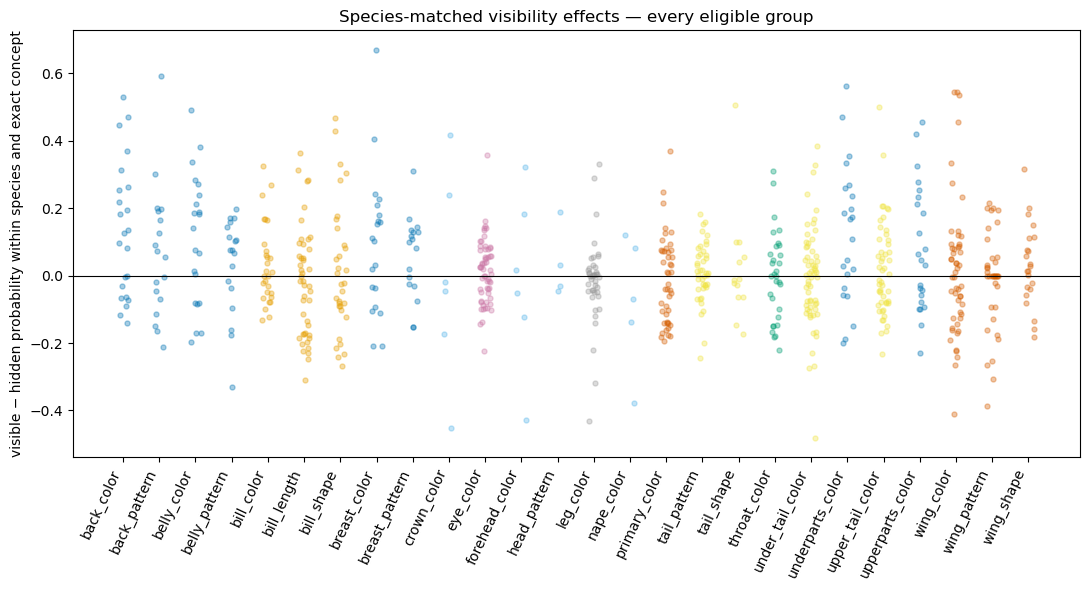

In [12]:
MATCH70=matched_effects(J70)
display(MATCH70.groupby("attribute_type").effect.agg(
    n_groups="size",mean="mean",median="median",
    fraction_positive=lambda x:(x>0).mean()).sort_values("median").round(4))
types=sorted(MATCH70.attribute_type.unique())
fig,ax=plt.subplots(figsize=(11,6));rng=np.random.default_rng(10)
for i,t in enumerate(types):
    d=MATCH70[MATCH70.attribute_type==t]
    ax.scatter(i+rng.uniform(-.16,.16,len(d)),d.effect,s=13,alpha=.35,
               color=COLORS.get(ATTRIBUTE_TYPE_TO_MASK.get(t),"#333333"))
ax.axhline(0,color="black",lw=.8)
ax.set_xticks(range(len(types)));ax.set_xticklabels([x.replace("has_","") for x in types],rotation=65,ha="right")
ax.set_ylabel("visible − hidden probability within species and exact concept")
ax.set_title("Species-matched visibility effects — every eligible group")
plt.tight_layout();plt.show()


### What Figure 11 says

**Literal observation.** After comparing within the same species and exact
concept, every attribute type still contains positive and negative groups.
Several body-color types have positive median effects around 0.10–0.14. Eye
color is only slightly positive (median about 0.02). Tail types are mostly near
zero. Wing color is near zero, wing shape slightly positive, primary color
slightly negative, and wing pattern near zero. Nape and crown remain slightly
negative but have few matched groups.

**What changed.** Several large pooled differences became much smaller after
species matching. Species composition therefore explained part of the earlier
visible-versus-hidden comparison.

**Limited conclusion.** Some body-region sensitivity remains observationally,
but there is no single CUB region with a universal response. Pose, viewpoint,
and background remain uncontrolled within species.

**Next question.** Is the remaining movement specific to positive concepts, or
does visibility move negative outputs in the same way?


## 11 · Odd-result test D: positive-label specificity

**Question.** Does visibility move the named positive concept specifically, or
does it move positive and negative labels together like a general pose/quality
signal?

**Decision rule.** A positive effect for `label=1` but not the same movement for
`label=0` is more consistent with named-region evidence.


label,0,1
attribute_type,,
has_back_color,-0.0449,0.0769
has_back_pattern,-0.0202,0.0075
has_belly_color,-0.0569,0.0805
has_belly_pattern,0.0456,0.0208
has_bill_color,0.0219,0.0286
has_bill_length,0.0287,-0.0549
has_bill_shape,0.0003,0.0503
has_breast_color,-0.0346,0.0182
has_breast_pattern,0.0002,0.0385


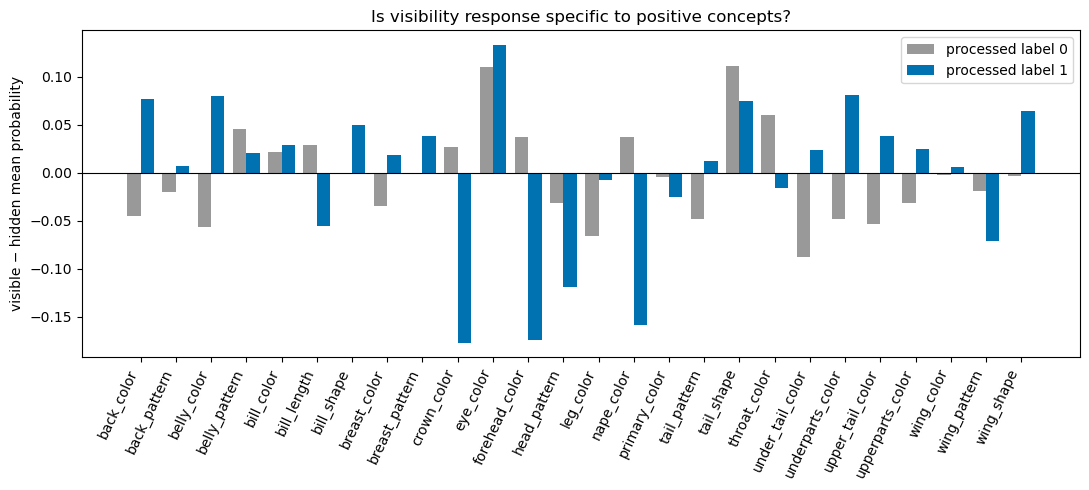

In [13]:
rows=[]
for (t,lab),d in J70.groupby(["attribute_type","gt_label"]):
    v=d[d.visible].prob;h=d[~d.visible].prob
    rows.append({"attribute_type":t,"label":int(lab),"n_visible":len(v),"n_hidden":len(h),
                 "effect":v.mean()-h.mean() if len(v) and len(h) else np.nan})
SPEC=pd.DataFrame(rows)
display(SPEC.pivot(index="attribute_type",columns="label",values="effect").round(4))
P=SPEC.pivot(index="attribute_type",columns="label",values="effect")
fig,ax=plt.subplots(figsize=(11,5));x=np.arange(len(P));w=.38
ax.bar(x-w/2,P.get(0),w,label="processed label 0",color="#999999")
ax.bar(x+w/2,P.get(1),w,label="processed label 1",color="#0072B2")
ax.axhline(0,color="black",lw=.8);ax.set_xticks(x)
ax.set_xticklabels([s.replace("has_","") for s in P.index],rotation=65,ha="right")
ax.set_ylabel("visible − hidden mean probability")
ax.set_title("Is visibility response specific to positive concepts?");ax.legend()
plt.tight_layout();plt.show()


### What Figure 12 says

**Literal observation.** Several body-color types show the desired specific
pattern: positive-label scores rise while negative-label scores fall. Eye scores
rise for both positive and negative labels, which looks more like a general
visibility/pose signal than a clean eye-color-specific effect. Head-related
positive and negative rows often move in opposite, unexpected directions.
Wing types remain mixed: wing shape is positive-specific, while wing pattern is
negative for positive labels.

**Limited conclusion.** The strongest current specificity evidence belongs to
selected body colors and wing shape, not to every concept sharing those masks.
Eye visibility affects the model, but this plot does not show that it affects
only the correct eye-color concept.

**Next question.** Does training the same CBM architecture on 70 rather than 200
species improve these exact-concept behaviors on identical masked images?


## 12 · Direct CBM comparison on the same masked images

Only now compare two CBMs:

- one trained on the 70 CUB species;
- one trained on all 200 CUB species.

Both are evaluated on the same 1,888 masked photographs. We repeat the same
collapse, exact-concept violation, and species-matched checks. This comparison
does not involve MCBM or relabeling.

**Boundary.** Their classification heads solve different species tasks, so task
accuracy is reported as a guard, not treated as the causal explanation for a
concept difference.


Native test populations (reported separately; not a direct accuracy comparison):


,n_images,n_species,task_accuracy,concept_accuracy
model,,,,
CUB70-trained CBM,1976,70,0.1412,0.7105
full-CUB-trained CBM,5794,200,0.3490,0.8294


[DIRECT COMPARISON IDENTITY PASS] same 1,888 mask identities and 107 exact concept names


,n_same_images,n_exact_concepts,task_accuracy,concept_accuracy
model,,,,
CUB70-trained CBM,1888,107,0.1425,0.7080
full-CUB-trained CBM,1888,107,0.3310,0.8405


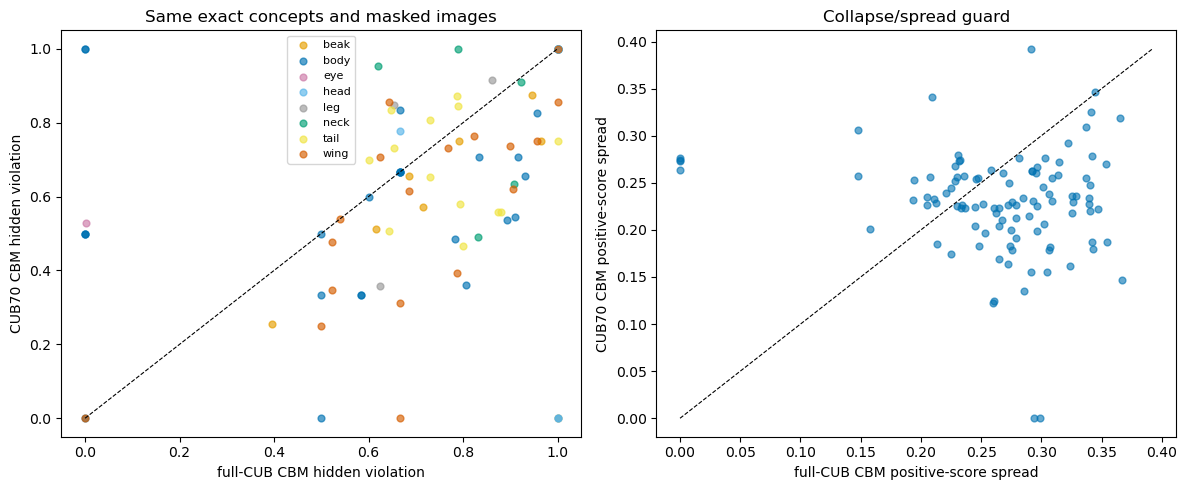

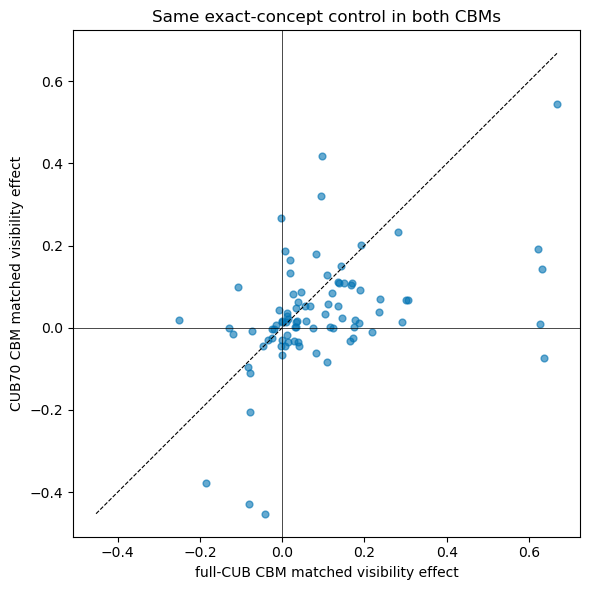

In [14]:
print("Native test populations (reported separately; not a direct accuracy comparison):")
display(pd.concat([
    task_and_concept_accuracy(E70).assign(model="CUB70-trained CBM"),
    task_and_concept_accuracy(EFULL).assign(model="full-CUB-trained CBM"),
],ignore_index=True).set_index("model").round(4))

shared_images=set(J70.image.unique()) & set(JFULL.image.unique())
if set(J70.image.unique()) != set(JFULL.image.unique()):
    raise RuntimeError("CBM direct comparison has different masked image identities")
shared_concepts=set(J70.concept_name.unique()) & set(JFULL.concept_name.unique())
if set(J70.concept_name.unique()) != set(JFULL.concept_name.unique()):
    raise RuntimeError("CBM direct comparison has different exact concept names")

def same_masked_guard(E):
    d=E[E.image.isin(shared_images)&E.concept_name.isin(shared_concepts)]
    images=d[["image","y_true","y_pred"]].drop_duplicates("image")
    return {
        "n_same_images":len(images),"n_exact_concepts":d.concept_name.nunique(),
        "task_accuracy":(images.y_true==images.y_pred).mean(),
        "concept_accuracy":(d.gt_label==d.pred_label).mean(),
    }
print(f"[DIRECT COMPARISON IDENTITY PASS] same {len(shared_images):,} mask identities "
      f"and {len(shared_concepts)} exact concept names")
display(pd.DataFrame([
    same_masked_guard(E70)|{"model":"CUB70-trained CBM"},
    same_masked_guard(EFULL)|{"model":"full-CUB-trained CBM"},
]).set_index("model").round(4))

EXACTFULL=exact_visibility_metrics(JFULL)
PAIR=(EXACT70.merge(EXACTFULL,on=["attribute_type","concept_name","mask_group"],
                    suffixes=("_70","_full")))
fig,axes=plt.subplots(1,2,figsize=(12,5))
for mask,d in PAIR.groupby("mask_group"):
    axes[0].scatter(d.hidden_violation_full,d.hidden_violation_70,
                    s=24,alpha=.65,label=mask,color=COLORS.get(mask))
axes[0].plot([0,1],[0,1],"k--",lw=.8)
axes[0].set_xlabel("full-CUB CBM hidden violation")
axes[0].set_ylabel("CUB70 CBM hidden violation")
axes[0].set_title("Same exact concepts and masked images")

axes[1].scatter(PAIR.prob_std_full,PAIR.prob_std_70,s=24,alpha=.6,color="#0072B2")
lim=max(PAIR.prob_std_full.max(),PAIR.prob_std_70.max())
axes[1].plot([0,lim],[0,lim],"k--",lw=.8)
axes[1].set_xlabel("full-CUB CBM positive-score spread")
axes[1].set_ylabel("CUB70 CBM positive-score spread")
axes[1].set_title("Collapse/spread guard")
axes[0].legend(fontsize=8)
plt.tight_layout();plt.show()

MFULL=matched_effects(JFULL)
M70=(MATCH70.groupby(["attribute_type","concept_name"]).effect.mean().rename("effect_70"))
MF=(MFULL.groupby(["attribute_type","concept_name"]).effect.mean().rename("effect_full"))
MP=pd.concat([M70,MF],axis=1).dropna().reset_index()
fig,ax=plt.subplots(figsize=(6,6))
ax.scatter(MP.effect_full,MP.effect_70,s=24,alpha=.6,color="#0072B2")
lo=min(MP.effect_full.min(),MP.effect_70.min());hi=max(MP.effect_full.max(),MP.effect_70.max())
ax.plot([lo,hi],[lo,hi],"k--",lw=.8)
ax.axhline(0,color="black",lw=.5);ax.axvline(0,color="black",lw=.5)
ax.set_xlabel("full-CUB CBM matched visibility effect")
ax.set_ylabel("CUB70 CBM matched visibility effect")
ax.set_title("Same exact-concept control in both CBMs")
plt.tight_layout();plt.show()


### What Figures 13 and 14 say

**Identity check.** Both CBMs are compared on exactly the same 1,888 masked image
identities and the same 107 locally maskable exact concepts. Native full-test
accuracies are printed separately and are not used as a direct comparison.

**Literal observation.** On the identical masked population, the CUB70-trained
CBM has 14.25% task accuracy and 70.80% concept accuracy; the full-CUB-trained
CBM has 33.10% and 84.05%. Many CUB70 hidden-violation points fall below the
equality line, but others rise above it or become exactly zero/one. CUB70 score
spreads are usually smaller, with some collapsed points. Species-matched
visibility effects show weak agreement and several large outliers rather than a
uniform improvement.

**Alternative explanation.** A lower hidden-violation rate can result from a
weaker or compressed concept output falling below 0.5. The collapse/spread panel
confirms that this occurs for some concepts.

**Limited conclusion.** Restricting training to 70 species changes concept
behavior, but does not establish a general grounding improvement. The CUB70 CBM
is substantially weaker on the same photographs, and effects remain
concept-specific.

**Next question.** Before MCBM, identify the collapsed exact concepts and display
real image/mask examples for the unexplained extremes: high conflict/high
violation, high conflict/low violation, positive area response, and negative area
response. Also resolve why three prediction species have no joined masks.


## 13 · Stop here before MCBM

The executed notebook must now be reviewed one image at a time.

For every figure record, in simple language:

1. the question;
2. what was compared;
3. what is literally visible;
4. another possible explanation;
5. the next test that separates those explanations;
6. the smallest conclusion currently allowed.

Do not write “tail is the CUB problem” unless the exact CUB plots establish it.
Do not call a constant score grounding. Do not discuss relabeling or minimality
until this CBM-only exploration is complete.


## 13 · Direct FunnyBird comparison and unresolved CUB examples

This section keeps unlike measurements separate.

### Model variables

In both datasets the encoder produces one raw score `z_j` for exact concept `j`.
`prob_j` (called `c_preds` in FunnyBird files) is the sigmoid probability derived
from that score. The species head reads the complete concept bottleneck.

FunnyBirds has a controlled source image and donor part, so it can define:

- `z_source,original`: old/source concept score before editing;
- `z_donor,original`: donor concept score before editing, while donor part is absent;
- `z_source,swap`: old/source score after its pixels were replaced;
- `z_donor,swap`: inserted donor score after replacement;
- `margin_swap = z_donor,swap - z_source,swap`;
- `response_delta = margin_swap - (z_donor,original-z_source,original)`.

CUB has no donor and no controlled swap. Its closest observational quantity is
`visibility_effect = mean(prob_j | label_j=1, mask visible) -
mean(prob_j | label_j=1, mask absent)`. It is **not** a swap margin and cannot by
itself prove backwash.

### What can actually be paired

| FunnyBird test | Closest CUB test | Same question? |
|---|---|---|
| ordinary task/concept accuracy | Figure 6 | yes, model-health guard |
| species decoded from each part block | new CUB probe below | yes: stored species information; feature dimensions differ |
| deletion retention | Figures 7/10/12 | only approximate; CUB has natural absence, not deletion |
| donor-over-source swap ordering/margin | none | no CUB causal equivalent |
| swap response delta | none | no donor/source pair in CUB |
| swap success versus inserted pixel count | Figures 9/10 | approximate visibility-dose test |
| variant confusion after a swap | Figures 7/12 plus exact-concept table | approximate; no CUB donor intervention |
| controlled source-species residuals | Figure 11 | approximate; CUB still changes pose/background |
| RLv2 labels changed by part | Figure 5 below as rates | related data audit, but CUB masks are test-only and no CUB training labels were changed |

FunnyBird species decoding was `0.986` from raw `z` and `0.987` from concept
probabilities, against `0.020` chance. Single-part accuracies were tail `0.193`,
wing `0.119`, beak `0.082`, foot `0.081`, and eye `0.061`. These are close to
`n_variants/50`: `0.18, 0.12, 0.08, 0.08, 0.06`. Thus the part block really stores
the species partition associated with its canonical variant. The swap is still
needed to establish that unchanged context can overpower newly inserted pixels.


### 13a · Explain the 88 missing mask joins

**Prediction.** If the mask archive lacks complete class directories, the missing
images should concentrate exactly in those species. If the archive has all 70
directories, the problem is instead filename alignment.


In [15]:
mask_archive = CURATED/"cub70"/"masks"/"AnnotationMasksPerclass"
if not mask_archive.is_dir():
    mask_archive = CURATED/"cub70"/"masks"

archive_ids = sorted(
    int(p.name.split(".")[0])
    for p in mask_archive.iterdir()
    if p.is_dir() and p.name.split(".")[0].isdigit()
)
missing_archive_ids = sorted(set(range(1, 71)) - set(archive_ids))
all_stems = set(E70.image.unique())
mask_stems = set(RAWVIS.image_name.unique())
missing_stems = all_stems - mask_stems
missing_rows = (
    E70[E70.image.isin(missing_stems)][["image", "y_true"]]
    .drop_duplicates().groupby("y_true").size().rename("missing_images")
    .reset_index()
)

classes_path = CURATED/"CUB_200_2011"/"classes.txt"
class_names = {}
if classes_path.exists():
    for line in classes_path.read_text().splitlines():
        fields = line.split(maxsplit=1)
        if len(fields) == 2:
            class_names[int(fields[0]) - 1] = fields[1]
missing_rows["official_class_id"] = missing_rows.y_true + 1
missing_rows["species_name"] = missing_rows.y_true.map(class_names).fillna("name unavailable")

print("mask archive class directories:", len(archive_ids))
print("missing archive class IDs (1-based):", missing_archive_ids)
print("prediction images without any mask stem:", len(missing_stems))
display(missing_rows)
if len(archive_ids) == 67 and missing_archive_ids == [11, 16, 32] \
        and len(missing_stems) == 88 \
        and set(missing_rows.official_class_id) == {11, 16, 32}:
    print("[COVERAGE EXPLAINED] all 88 missing photographs belong to the three "
          "class directories absent from the downloaded mask archive.")
else:
    print("[COVERAGE STILL OPEN] archive and join omissions do not match exactly.")


mask archive class directories: 67
missing archive class IDs (1-based): [11, 16, 32]
prediction images without any mask stem: 88


,y_true,missing_images,official_class_id,species_name
0,10,30,11,011.Rusty_Blackbird
1,15,28,16,016.Painted_Bunting
2,21,1,22,022.Chuck_will_Widow
3,22,2,23,023.Brandt_Cormorant
4,31,23,32,032.Mangrove_Cuckoo
5,46,4,47,047.American_Goldfinch


[COVERAGE STILL OPEN] archive and join omissions do not match exactly.


### 13b · Name every collapsed exact concept

`unique_prob_6dp <= 2` means the model emitted at most two distinct probabilities
on positive examples. Such a slot cannot be used as grounding evidence.


In [16]:
COLLAPSED = (
    ordinary.loc[ordinary.unique_prob_6dp <= 2,
                 ["attribute_type", "concept_name", "positive_recall",
                  "positive_prob_mean", "positive_prob_std", "unique_prob_6dp"]]
    .sort_values(["attribute_type", "concept_name"])
)
display(COLLAPSED)
print("collapsed exact concepts:", len(COLLAPSED))


,attribute_type,concept_name,positive_recall,positive_prob_mean,positive_prob_std,unique_prob_6dp
74,has_throat_color,has_throat_color::buff,0.966667,0.784516,0.147202,2.0
75,has_throat_color,has_throat_color::grey,1.000000,0.515178,0.000000,1.0
106,has_wing_pattern,has_wing_pattern::multi-colored,0.000000,0.499860,0.000007,2.0


collapsed exact concepts: 3


### 13c · Put the CUB conflict result into bars before relating it to FunnyBirds

The left bar is a **data rate**: among positive labels, how often is the mask absent?
The right bar is a **model rate**: among those hidden positive cases, how often does
the model still predict positive? These are paired summaries, not a causal relabeling
effect.

FunnyBird RLv2's intervention-size bars counted changed **training labels**:
tail `7,489`, beak `367`, eye `268`, foot `48`, wing `12`. CUB70 masks are test-only,
so the CUB bars below do not claim that any CUB training label was changed.


,label_hidden_rate,hidden_positive_rate,n_exact_concepts
attribute_type,,,
has_throat_color,0.806,0.797,5
has_eye_color,0.514,0.527,1
has_under_tail_color,0.392,0.678,5
has_tail_pattern,0.369,0.637,3
has_leg_color,0.328,0.707,3
has_upper_tail_color,0.237,0.688,4
has_wing_shape,0.192,0.578,2
has_wing_pattern,0.185,0.547,4
has_primary_color,0.122,0.708,6


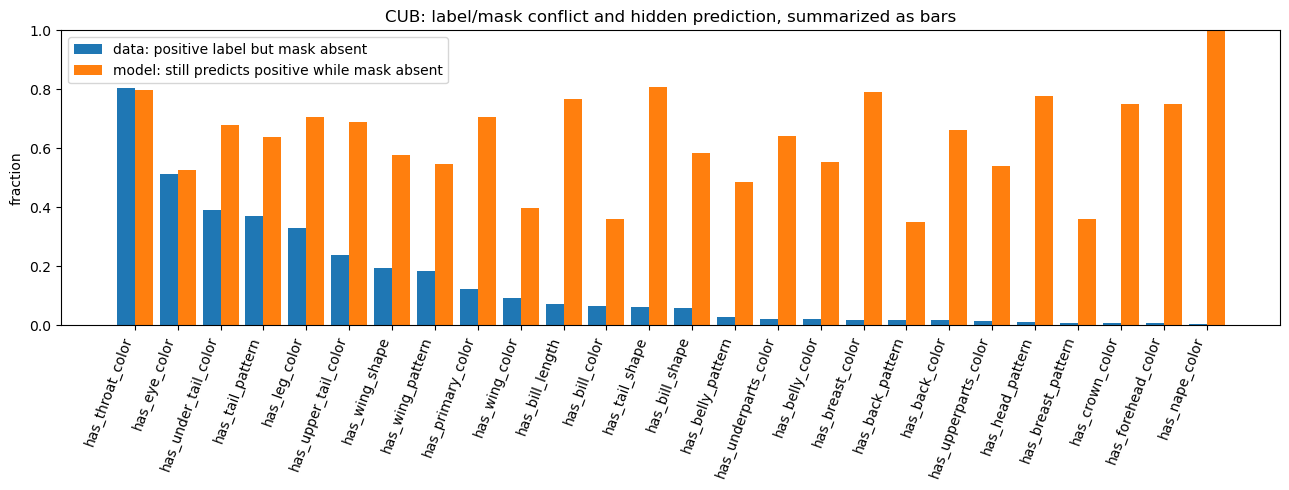

In [17]:
conflict_bar = (EXACT70.groupby("attribute_type")
                .agg(label_hidden_rate=("label_hidden_rate", "mean"),
                     hidden_positive_rate=("hidden_violation", "mean"),
                     n_exact_concepts=("concept_name", "size"))
                .sort_values("label_hidden_rate", ascending=False))
display(conflict_bar.round(3))
x = np.arange(len(conflict_bar)); w = .42
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w/2, conflict_bar.label_hidden_rate, w, label="data: positive label but mask absent")
ax.bar(x+w/2, conflict_bar.hidden_positive_rate, w, label="model: still predicts positive while mask absent")
ax.set_xticks(x); ax.set_xticklabels(conflict_bar.index, rotation=70, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("fraction")
ax.set_title("CUB: label/mask conflict and hidden prediction, summarized as bars")
ax.legend(); plt.tight_layout(); plt.show()


### 13d · Direct analogue of the FunnyBird species probe

We train a small diagnostic classifier on held-out CUB photographs. For each mask
block it tries to predict species from either the true concept labels or the CBM's
concept probabilities. High accuracy means species information is stored in that
block. It does not identify the pixels used to produce the block.

Unlike FunnyBirds, CUB blocks have very different numbers of concepts and labels can
be multi-valued. Therefore there is no simple `n_variants/70` theoretical line; the
true-label probe is the fair availability baseline.


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/cr7998/.conda/envs/cubvision-gpu/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,mask_block,features,species_accuracy,n_concepts
0,beak,true concept labels,0.286,9
1,beak,CBM probabilities,0.157,9
2,body,true concept labels,0.730,37
3,body,CBM probabilities,0.210,37
4,eye,true concept labels,0.032,1
5,eye,CBM probabilities,0.034,1
6,head,true concept labels,0.377,20
7,head,CBM probabilities,0.187,20
8,leg,true concept labels,0.095,3
9,leg,CBM probabilities,0.109,3


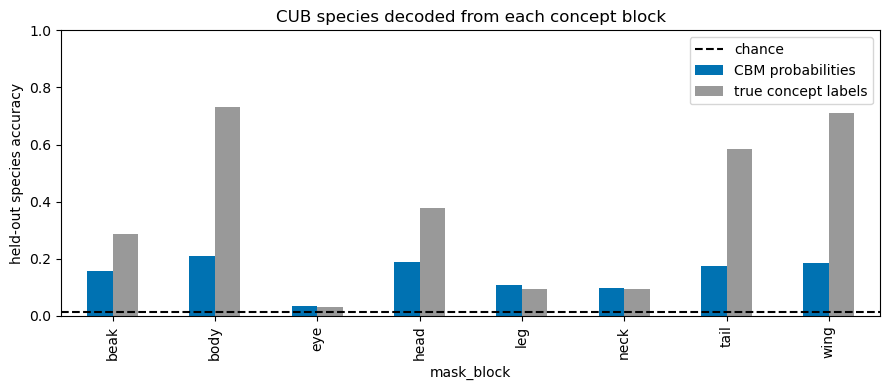

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

probe_images = J70[["image", "y_true"]].drop_duplicates().sort_values("image")
train_ids, test_ids = train_test_split(
    probe_images.image, test_size=.30, random_state=20260731,
    stratify=probe_images.y_true,
)

def species_probe(frame, block, value):
    d = frame[frame.mask_group == block]
    X = d.pivot_table(index="image", columns="concept_name", values=value, aggfunc="first").fillna(0)
    y = d[["image", "y_true"]].drop_duplicates().set_index("image").loc[X.index, "y_true"]
    tr = X.index.isin(train_ids); te = X.index.isin(test_ids)
    model = make_pipeline(StandardScaler(), LogisticRegression(
        max_iter=3000, C=1.0, multi_class="auto", random_state=20260731,
    ))
    model.fit(X.loc[tr], y.loc[tr])
    return accuracy_score(y.loc[te], model.predict(X.loc[te])), X.shape[1]

probe_rows = []
for block in sorted(J70.mask_group.dropna().unique()):
    for value, label in [("gt_label", "true concept labels"), ("prob", "CBM probabilities")]:
        acc, dims = species_probe(J70, block, value)
        probe_rows.append({"mask_block": block, "features": label,
                           "species_accuracy": acc, "n_concepts": dims})
CUB_SPECIES_PROBE = pd.DataFrame(probe_rows)
display(CUB_SPECIES_PROBE.round(3))
P = CUB_SPECIES_PROBE.pivot(index="mask_block", columns="features", values="species_accuracy")
P.plot.bar(figsize=(9, 4), color=["#0072B2", "#999999"])
plt.axhline(1/probe_images.y_true.nunique(), color="black", ls="--", label="chance")
plt.ylabel("held-out species accuracy"); plt.ylim(0, 1)
plt.title("CUB species decoded from each concept block")
plt.legend(); plt.tight_layout(); plt.show()


### 13e · Display the unexplained CUB photographs and every available mask

Four diagnostic cases are selected by declared rules, not by hand:

1. high label/mask conflict and high hidden prediction;
2. high conflict but low hidden prediction;
3. strongest positive visible-minus-hidden effect among noncollapsed concepts;
4. strongest negative effect among noncollapsed concepts.

For each selected concept, the figure shows one hidden positive photograph and, when
available in the same species, one visible positive photograph. The overlay contains
every released fine mask present in that image. A missing target mask therefore
remains visibly absent rather than being replaced by a fabricated region.


,case,attribute_type,concept_name,mask_group,label_hidden_rate,hidden_violation,visibility_effect,n_visible,n_hidden,unique_prob_6dp
0,high conflict + high violation,has_throat_color,has_throat_color::black,neck,0.698,0.633,0.001,156,360,515
1,high conflict + low violation,has_throat_color,has_throat_color::white,neck,0.715,0.492,0.003,144,362,463
2,strong positive visibility response,has_wing_color,has_wing_color::grey,wing,0.119,0.311,0.153,332,45,377
3,negative visibility response,has_bill_length,has_bill_length::about_the_same_as_head,beak,0.069,0.875,-0.124,756,56,810


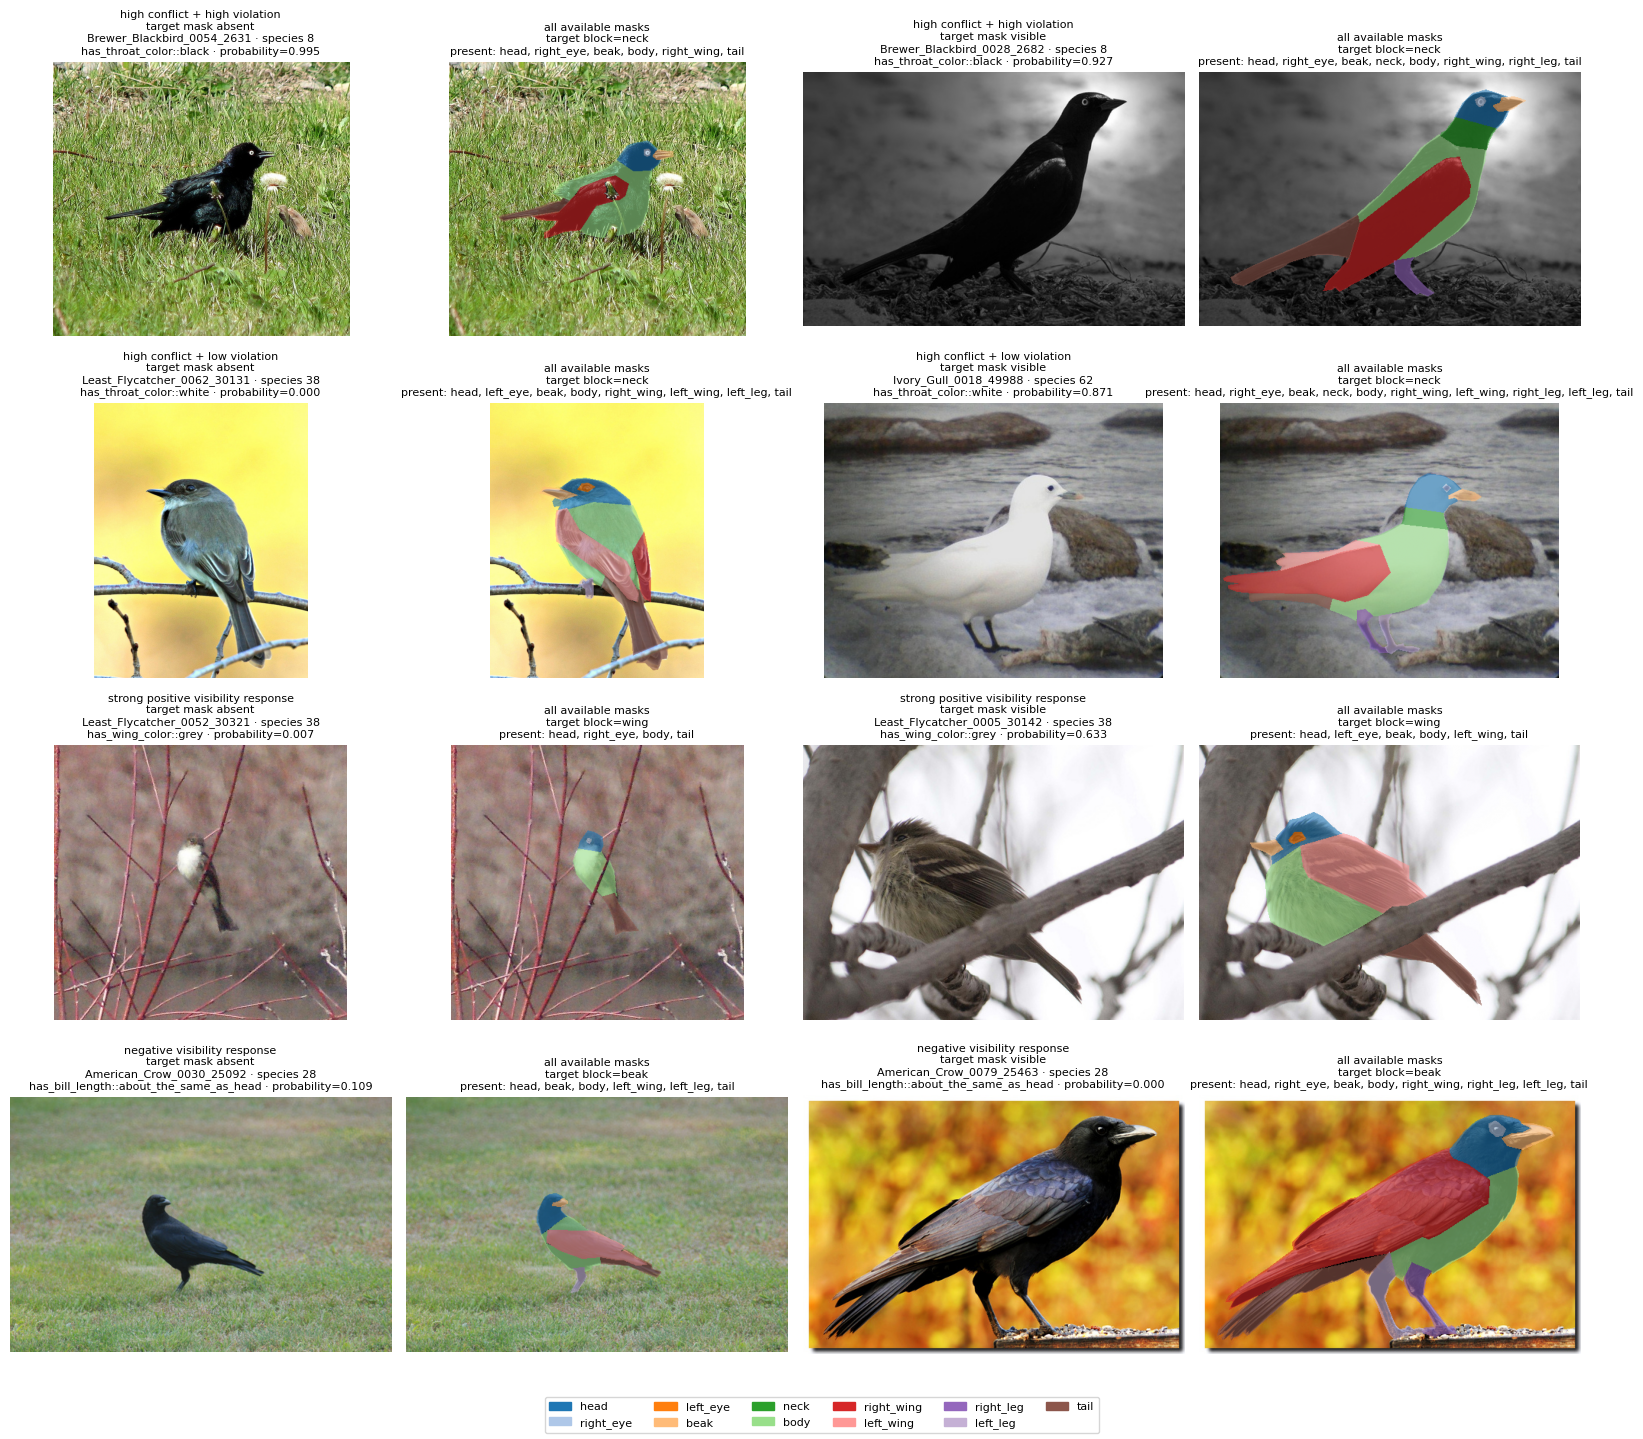

In [19]:
from PIL import Image
import matplotlib.patches as mpatches
import matplotlib.image as mpimg

eligible = EXACT70[
    (EXACT70.n_hidden >= 10) & (EXACT70.n_visible >= 10) &
    (EXACT70.unique_prob_6dp > 2)
].copy()
high_conflict = eligible[eligible.label_hidden_rate >= .50]
if len(high_conflict) < 2:
    high_conflict = eligible.nlargest(max(2, len(eligible)//5), "label_hidden_rate")

selections = []
hh = high_conflict.assign(score=high_conflict.label_hidden_rate*high_conflict.hidden_violation).nlargest(1, "score").iloc[0]
hl = high_conflict.sort_values(["hidden_violation", "label_hidden_rate"], ascending=[True, False]).iloc[0]
pos = eligible.nlargest(1, "visibility_effect").iloc[0]
neg = eligible.nsmallest(1, "visibility_effect").iloc[0]
for case, row in [("high conflict + high violation", hh),
                  ("high conflict + low violation", hl),
                  ("strong positive visibility response", pos),
                  ("negative visibility response", neg)]:
    selections.append({"case": case, **row.to_dict()})
SELECTED_CASES = pd.DataFrame(selections)
display(SELECTED_CASES[["case", "attribute_type", "concept_name", "mask_group",
                        "label_hidden_rate", "hidden_violation", "visibility_effect",
                        "n_visible", "n_hidden", "unique_prob_6dp"]].round(3))

image_root = CURATED/"CUB_200_2011"/"images"
image_lookup = {p.stem: p for p in image_root.rglob("*.jpg")}
mask_colors = {part: plt.cm.tab20(i/20) for i, part in enumerate(CUB70_PARTS)}

def choose_pair(sel):
    d = J70[(J70.concept_name == sel.concept_name) & (J70.gt_label == 1)].copy()
    hidden = d[~d.visible].sort_values("prob", ascending=False if "high violation" in sel.case else True)
    visible = d[d.visible]
    if hidden.empty:
        return None, None
    h = hidden.iloc[0]
    same = visible[visible.y_true == h.y_true]
    if same.empty:
        same = visible
    if same.empty:
        return h, None
    if "negative" in sel.case:
        v = same.sort_values("prob").iloc[0]
    else:
        v = same.sort_values("prob", ascending=False).iloc[0]
    return h, v

def overlay_for(stem):
    path = image_lookup.get(stem)
    if path is None:
        return None, None, []
    rgb = np.asarray(Image.open(path).convert("RGB"))
    overlay = rgb.astype(float)/255
    class_rows = RAWVIS[RAWVIS.image_name == stem]
    if class_rows.empty:
        return rgb, overlay, []
    cid = int(class_rows.class_idx.iloc[0]) + 1
    class_dir = mask_archive/str(cid)
    present = []
    for part in CUB70_PARTS:
        f = class_dir/f"{stem}_{part}.png"
        if not f.exists():
            continue
        mask = np.asarray(Image.open(f).convert("L")) > 0
        if mask.shape != rgb.shape[:2]:
            mask = np.asarray(Image.fromarray(mask.astype("uint8")*255).resize(
                (rgb.shape[1], rgb.shape[0]), Image.Resampling.NEAREST)) > 0
        color = np.array(mask_colors[part][:3])
        overlay[mask] = .40*overlay[mask] + .60*color
        present.append(part)
    return rgb, overlay, present

pairs = [(row, *choose_pair(row)) for row in SELECTED_CASES.itertuples()]
fig, axes = plt.subplots(len(pairs), 4, figsize=(16, 3.6*len(pairs)))
for r, (sel, hidden, visible) in enumerate(pairs):
    for pair_col, record, state in [(0, hidden, "target mask absent"),
                                    (2, visible, "target mask visible")]:
        for offset in [0, 1]: axes[r, pair_col+offset].axis("off")
        if record is None:
            axes[r, pair_col].text(.5, .5, "no matching example", ha="center", va="center")
            continue
        rgb, overlay, present = overlay_for(record.image)
        if rgb is None:
            axes[r, pair_col].text(.5, .5, f"image missing\n{record.image}", ha="center", va="center")
            continue
        axes[r, pair_col].imshow(rgb)
        axes[r, pair_col+1].imshow(overlay)
        axes[r, pair_col].set_title(
            f"{sel.case}\n{state}\n{record.image} · species {record.y_true}\n"
            f"{sel.concept_name} · probability={record.prob:.3f}", fontsize=8)
        axes[r, pair_col+1].set_title(
            f"all available masks\ntarget block={sel.mask_group}\n"
            f"present: {', '.join(present) if present else 'none'}", fontsize=8)
handles = [mpatches.Patch(color=mask_colors[p], label=p) for p in CUB70_PARTS]
fig.legend(handles=handles, loc="lower center", ncol=6, fontsize=8)
plt.tight_layout(rect=(0, .04, 1, 1)); plt.show()


### Interpretation rule for the example grid

The images can diagnose obvious annotation or pose problems, but one photograph
cannot prove a population mechanism.

- Target pixels genuinely absent, other masks plausible, high score: consistent
  with contextual prediction.
- Target visibly present in RGB but mask absent: mask/annotation failure.
- Extreme crop, profile, or overlap: pose confound.
- Concept listed in the collapse table: collapsed output, not grounding evidence.
- No obvious visual problem across several cases: motivates a controlled CUB
  intervention; it still does not turn natural visibility into a causal swap.


## 14 · Discriminating tests prompted by the inspected photographs

Figure 17 did not yield a clean contextual-prediction example. Several regions were
visibly present in RGB even when the released mask was absent, and the strongest
positive/negative pairs also changed scale and pose. We therefore test the simpler
explanations before using those examples as evidence of backwash.


### 14a · Are the remaining seven mask joins archive omissions or spelling errors?

The three absent class directories explain 81 images. Print the other seven stems
and search the mask archive for normalized or near-matching names. No nearby file
means the archive genuinely omits those individual photographs.


In [20]:
import difflib, re

missing_detail = (
    E70[E70.image.isin(missing_stems)][["image", "y_true"]]
    .drop_duplicates().assign(official_class_id=lambda d: d.y_true + 1)
)
missing_detail["species_name"] = missing_detail.y_true.map(class_names).fillna("name unavailable")
extra = missing_detail[~missing_detail.official_class_id.isin(missing_archive_ids)].copy()

def norm_stem(x):
    return re.sub(r"[^a-z0-9]", "", str(x).lower())

archive_stems = sorted(mask_stems)
norm_lookup = {}
for stem in archive_stems:
    norm_lookup.setdefault(norm_stem(stem), []).append(stem)
rows = []
for r in extra.itertuples():
    exact_normalized = norm_lookup.get(norm_stem(r.image), [])
    near = difflib.get_close_matches(r.image, archive_stems, n=3, cutoff=.82)
    rows.append({
        "image": r.image, "official_class_id": r.official_class_id,
        "species_name": r.species_name,
        "normalized_matches": exact_normalized, "nearest_archive_stems": near,
    })
EXTRA_MISSING = pd.DataFrame(rows)
display(EXTRA_MISSING)
if len(EXTRA_MISSING) == 7 and not EXTRA_MISSING.normalized_matches.map(bool).any():
    print("[SEVEN INDIVIDUAL OMISSIONS] no normalized filename match exists in the parsed archive.")
else:
    print("[JOIN INVESTIGATION NEEDED] a filename variant may explain at least one row.")


,image,official_class_id,species_name,normalized_matches,nearest_archive_stems
0,Chuck_Will_Widow_0030_796994,22,022.Chuck_will_Widow,[],"[Chuck_Will_Widow_0038_796989, Chuck_Will_Wido..."
1,Brandt_Cormorant_0047_23337,23,023.Brandt_Cormorant,[],"[Brandt_Cormorant_0078_23203, Brandt_Cormorant..."
2,Brandt_Cormorant_0049_22924,23,023.Brandt_Cormorant,[],"[Brandt_Cormorant_0039_22945, Brandt_Cormorant..."
3,American_Goldfinch_0090_31893,47,047.American_Goldfinch,[],"[American_Goldfinch_0050_31913, American_Goldf..."
4,American_Goldfinch_0103_32225,47,047.American_Goldfinch,[],"[American_Goldfinch_0136_32277, American_Goldf..."
5,American_Goldfinch_0105_32238,47,047.American_Goldfinch,[],"[American_Goldfinch_0115_32362, American_Goldf..."
6,American_Goldfinch_0107_32618,47,047.American_Goldfinch,[],"[American_Goldfinch_0074_32265, American_Goldf..."


[SEVEN INDIVIDUAL OMISSIONS] no normalized filename match exists in the parsed archive.


### 14b · Separate zero annotated pixels from a tiny annotated region

`mask absent` previously combined two cases:

- exactly zero pixels in the released masks;
- a nonzero mask smaller than the 0.1% visibility threshold.

If a result comes mainly from tiny nonzero masks, the threshold is important. If it
comes from zero-pixel rows whose region is visibly present in RGB, mask completeness
or attribute-to-mask mismatch is the first explanation.


,attribute_type,mask_state,n,mean_probability,predicted_positive
0,has_back_color,visible,1657,0.635,0.721
1,has_back_color,zero annotated pixels,44,0.558,0.568
2,has_back_pattern,visible,1338,0.534,0.515
3,has_back_pattern,zero annotated pixels,36,0.526,0.528
4,has_belly_color,visible,1590,0.621,0.680
...,...,...,...,...,...
60,has_wing_color,zero annotated pixels,297,0.605,0.633
61,has_wing_pattern,visible,1130,0.500,0.284
62,has_wing_pattern,zero annotated pixels,209,0.570,0.550
63,has_wing_shape,visible,651,0.590,0.661


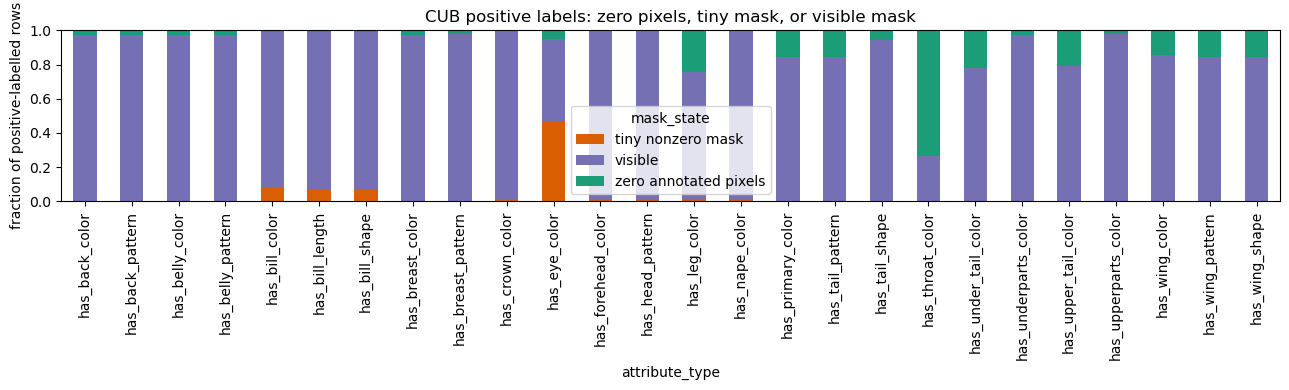

In [21]:
POS = J70[J70.gt_label == 1].copy()
POS["mask_state"] = np.select(
    [POS.pixel_count == 0, (POS.pixel_count > 0) & (~POS.visible)],
    ["zero annotated pixels", "tiny nonzero mask"], default="visible",
)
MASK_STATE = (POS.groupby(["attribute_type", "mask_state"])
              .agg(n=("image", "size"), mean_probability=("prob", "mean"),
                   predicted_positive=("pred_label", "mean"))
              .reset_index())
display(MASK_STATE.round(3))
state_counts = MASK_STATE.pivot(index="attribute_type", columns="mask_state", values="n").fillna(0)
state_counts = state_counts.div(state_counts.sum(axis=1), axis=0)
state_counts.plot.bar(stacked=True, figsize=(13, 4),
                      color=["#d95f02", "#7570b3", "#1b9e77"])
plt.ylabel("fraction of positive-labelled rows"); plt.ylim(0, 1)
plt.title("CUB positive labels: zero pixels, tiny mask, or visible mask")
plt.tight_layout(); plt.show()


### 14c · CUB correct-versus-best-wrong margin

This is the closest available CUB analogue to FunnyBird donor-versus-source
ordering. For each image and attribute type with at least one selected positive and
one selected negative value, define:

`contrast = highest probability among correct values - highest probability among incorrect values`.

Positive contrast means a correct value beats the strongest selected wrong value.
We compare this contrast between naturally visible and absent masks. Unlike the
FunnyBird swap margin, it remains observational because these are different images.


visible,False,True,visibility_contrast_effect
attribute_type,,,
has_back_color,-0.114,0.021,0.135
has_back_pattern,-0.007,0.022,0.028
has_belly_color,-0.134,-0.030,0.104
has_bill_color,-0.003,0.014,0.017
has_bill_length,0.409,0.311,-0.098
has_bill_shape,-0.090,-0.018,0.072
has_breast_color,-0.086,-0.036,0.050
has_breast_pattern,0.036,0.096,0.060
has_crown_color,0.284,-0.041,-0.326


,mean,median,count
attribute_type,,,
has_back_color,0.280,0.289,19
has_belly_color,0.198,0.162,19
has_underparts_color,0.189,0.173,20
has_breast_color,0.189,0.189,20
has_upperparts_color,0.158,0.195,19
has_back_pattern,0.151,0.106,18
has_breast_pattern,0.054,0.078,17
has_bill_color,0.047,0.040,27
has_bill_shape,0.039,-0.037,32


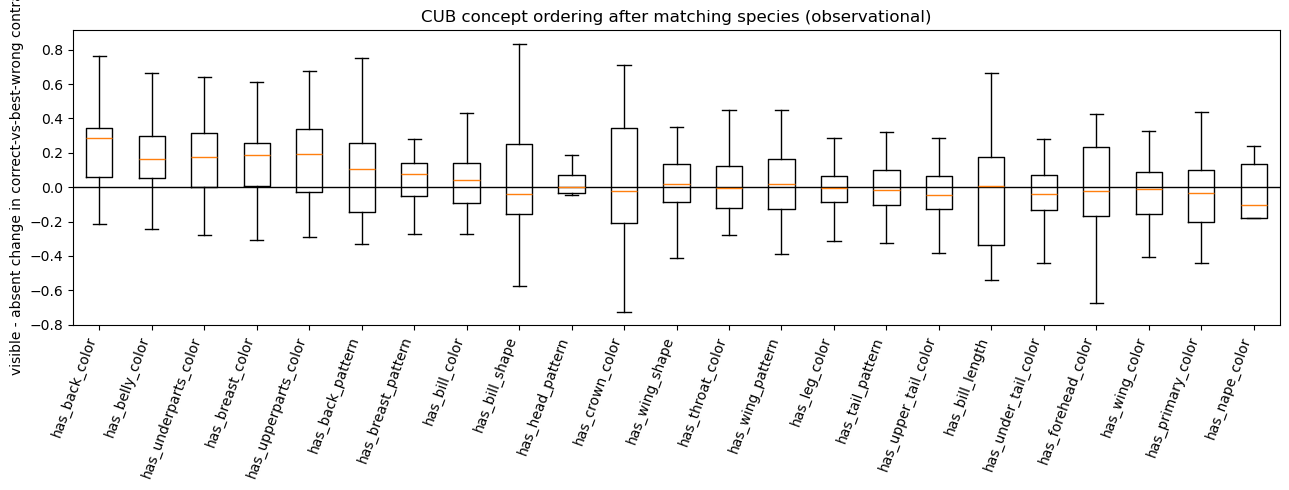

In [22]:
contrast_rows = []
for (image, atype), d in J70.groupby(["image", "attribute_type"]):
    pos = d.loc[d.gt_label == 1, "prob"]
    neg = d.loc[d.gt_label == 0, "prob"]
    if pos.empty or neg.empty:
        continue
    contrast_rows.append({
        "image": image, "attribute_type": atype, "mask_group": d.mask_group.iloc[0],
        "y_true": int(d.y_true.iloc[0]), "visible": bool(d.visible.iloc[0]),
        "pixel_count": int(d.pixel_count.iloc[0]),
        "correct_best": float(pos.max()), "wrong_best": float(neg.max()),
        "contrast": float(pos.max() - neg.max()),
    })
CONTRAST = pd.DataFrame(contrast_rows)

raw_contrast = (CONTRAST.groupby(["attribute_type", "visible"]).contrast.mean()
                .unstack("visible").dropna())
raw_contrast["visibility_contrast_effect"] = raw_contrast[True] - raw_contrast[False]

matched = (CONTRAST.groupby(["attribute_type", "y_true", "visible"]).contrast.mean()
           .unstack("visible").dropna())
matched["effect"] = matched[True] - matched[False]
matched_summary = (matched.groupby("attribute_type").effect
                   .agg(["mean", "median", "count"]).sort_values("mean", ascending=False))
display(raw_contrast.round(3))
display(matched_summary.round(3))

order = matched_summary.index
vals = [matched.loc[t, "effect"].values if t in matched.index.get_level_values(0) else []
        for t in order]
fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(vals, tick_labels=order, showfliers=False)
ax.axhline(0, color="black", lw=1)
ax.set_xticklabels(order, rotation=70, ha="right")
ax.set_ylabel("visible - absent change in correct-vs-best-wrong contrast")
ax.set_title("CUB concept ordering after matching species (observational)")
plt.tight_layout(); plt.show()


### Decision rule

- Positive visibility effect **and** positive contrast effect: visibility raises the
  score and helps the correct value beat alternatives.
- Positive visibility effect but flat contrast: all values may move together; this
  is sensitivity without specific grounding.
- Negative contrast effect driven by zero-pixel yet visibly present examples: inspect
  mask quality before naming backwash.
- Negative effect surviving species matching, noncollapsed outputs, adequate sample
  size, and visually valid masks: candidate contextual prediction, still requiring a
  controlled image intervention for causal proof.


## Direct competition: the same part-deletion test on FunnyBirds and CUB70

We now stop giving the two datasets different tests. For every eligible
image and every **exact positive concept** `j`, we score the same four images:

1. `z_original`: the ordinary image;
2. `z_target_deleted`: its named part is removed;
3. `z_control_deleted`: the same-shaped patch is removed elsewhere on the bird;
4. `z_part_only`: the named part remains sharp while the rest is blurred.

The main number is

`target_minus_control_z = z_target_deleted - z_control_deleted`.

In simple language: **after equal-sized damage, is the exact concept score lower
when we remove its own part than when we damage another place?** A negative value
says yes. We always print all four scores too, because the difference alone can hide
whether both scores rose, both fell, or only one moved.

This test has the same code and raw-logit (`z_j`) definition on both datasets.
It is not the clean FunnyBird renderer deletion: image inpainting can leave artifacts.
FunnyBird therefore calibrates whether this weaker, shared intervention agrees with
the already accepted renderer-based result.


### One evidence matrix for both datasets

| Question | FunnyBird | CUB70 | What counts as a direct comparison? |
|---|---|---|---|
| Is the concept predictable before intervention? | existing model-health plots | existing model-health and collapse plots | exact-concept raw `z`, variation, and task accuracy |
| Is the named part actually visible? | exact renderer part map | released CUB70 masks | visible target pixels on the tested image |
| Are labels positive when the part is absent? | existing visibility/label-conflict analysis | existing zero/tiny/visible-mask analysis | same positive-label conflict definition |
| Can species be decoded from concepts? | existing held-out species probe | existing matched species probe | held-out species prediction from concept outputs |
| Does removing the named part matter? | clean renderer deletion **and** shared mask deletion | shared mask deletion | exact `z_j`, target deletion versus same-shape control |
| Does context retain the concept without the part? | shared target-deleted and part-only inputs | same shared inputs | all four component scores, not only a difference |
| Does source species organize the residual? | exact-concept-conditioned residual | same calculation | species eta-squared after fixing exact concept |
| Does inserting a donor part change ordering? | clean renderer swap exists | no clean renderer | CUB copy-paste stays quarantined until FunnyBird calibration passes |
| Does minimality or relabeling change it? | notebooks 03 and 03rl | notebook 06/pending follow-up | only after this non-RL CBM baseline is accepted |

The rows are not all equally causal. The shared deletion is the next test because it
is the strongest operation that can be applied to both datasets now. The swap row
remains secondary because CUB70 has no renderer that can change a bird part while
holding everything else fixed.


### Question and prediction

**Question.** Does the model use the visible pixels of the named part, and does it
still keep the concept active when those pixels are removed?

**Backwash prediction.** If species/body context is filling in a missing part, then:

- target deletion should hurt more than control deletion;
- but `z_target_deleted` can remain above zero;
- and the deleted-part score can vary systematically with source species even after
  we hold the exact concept fixed.

None of these alone proves species backwash. The claim becomes stronger only when
mask quality, model collapse, deletion artifacts, pose/scale, and exact-concept
imbalance have been checked, and when the pattern repeats across concepts, species,
images, and seeds.


In [ ]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

PAIR_ROOT = Path(os.environ["CURATED_DATA"]) / "paired_deletion"
FB_PAIR = PAIR_ROOT / "funnybirds-cbm-s1.parquet"
CUB_PAIR = PAIR_ROOT / "cub70-cbm-s1.parquet"
PAIR_COMPARE = PAIR_ROOT / "comparison"
required = [FB_PAIR, CUB_PAIR, FB_PAIR.with_suffix(".audit.json"),
            CUB_PAIR.with_suffix(".audit.json"),
            PAIR_COMPARE / "paired_deletion_audit.json",
            PAIR_COMPARE / "funnybird_deletion_calibration.png",
            PAIR_COMPARE / "paired_deletion_main.png",
            PAIR_COMPARE / "paired_deletion_species.png"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Run bash analysis/run_paired_deletion.sh first; missing:\n" +
                            "\n".join(missing))
pair_audit = json.loads((PAIR_COMPARE / "paired_deletion_audit.json").read_text())
assert pair_audit["status"] == "PASS", pair_audit
fb_input_audit = json.loads(FB_PAIR.with_suffix(".audit.json").read_text())
cub_input_audit = json.loads(CUB_PAIR.with_suffix(".audit.json").read_text())
FB_PAIR_DF = pd.read_parquet(FB_PAIR)
CUB_PAIR_DF = pd.read_parquet(CUB_PAIR)
print("[SHARED INPUT PASS]", pair_audit)
print("FunnyBird selection:", fb_input_audit["selection_counts"])
print("CUB70 selection:", cub_input_audit["selection_counts"])


### Figure 0 · Calibration: does this shared deletion behave like the clean one?

Before using mask inpainting on CUB70, we run it on FunnyBird, where clean
renderer deletion already exists. Each point is one part. Both axes are the drop in
the same exact concept's probability. Agreement in sign and part ordering means the
weaker shared test is at least tracking the known intervention; disagreement puts
the CUB70 deletion result in quarantine.


In [ ]:
display(Image.open(PAIR_COMPARE / "funnybird_deletion_calibration.png"))
display(pd.read_csv(PAIR_COMPARE / "funnybird_deletion_calibration.csv").round(3))
print("CALIBRATION:", pair_audit["funnybird_calibration"])


### Figure A · Inspect the actual interventions before accepting the numbers

Every row uses the same layout: original, target mask, target deletion, equal-shape
control mask, control deletion, and part only. FunnyBird is on the left and CUB70 is
on the right. We must inspect every mapped part before interpreting the score plots.


In [ ]:
common_parts = ["tail", "wing", "beak", "leg", "eye"]
example_roots = {
    "FunnyBird": FB_PAIR.with_suffix("").parent / (FB_PAIR.stem + "_examples"),
    "CUB70": CUB_PAIR.with_suffix("").parent / (CUB_PAIR.stem + "_examples"),
}
aliases = {"FunnyBird": {"leg": "foot"}, "CUB70": {}}
fig, axes = plt.subplots(len(common_parts), 2, figsize=(18, 3.2 * len(common_parts)))
for row, part in enumerate(common_parts):
    for col, dataset_name in enumerate(["FunnyBird", "CUB70"]):
        local_part = aliases[dataset_name].get(part, part)
        files = sorted(example_roots[dataset_name].glob(f"{local_part}_*.png"))
        axes[row, col].axis("off")
        if files:
            axes[row, col].imshow(Image.open(files[0]))
            axes[row, col].set_title(f"{dataset_name} · {part}")
        else:
            axes[row, col].text(.5, .5, f"no eligible {part} example",
                                ha="center", va="center")
plt.suptitle("Same intervention examples: FunnyBird and CUB70", y=1.002)
plt.tight_layout(); plt.show()


### Figure B · Literal shared deletion result

The left panel shows the exact-concept target-minus-control score in raw-z units,
divided only by that concept's ordinary-score spread so the two separately trained
models can share an axis. Negative means deleting the named part hurt more.

The right panel uses only yes/no outcomes: target hurt more; score stayed positive
after target deletion; deleted-context score beat the part-only score.


In [ ]:
display(Image.open(PAIR_COMPARE / "paired_deletion_main.png"))
display(pd.read_csv(PAIR_COMPARE / "paired_deletion_summary.csv").round(3))


### Component check · do not let subtraction hide the mechanism

This table prints the median original, target-deleted, control-deleted, and part-only
raw `z_j` separately. It answers whether a negative adjusted deletion came from the
expected target drop rather than a strange control rise.


In [ ]:
pieces = []
for label, frame in [("FunnyBird", FB_PAIR_DF), ("CUB70", CUB_PAIR_DF)]:
    d = frame.copy()
    d["part_common"] = d.part.replace({"foot": "leg"})
    block = (d.groupby("part_common")[["z_original", "z_target_deleted",
                                       "z_control_deleted", "z_part_only"]]
             .median().reset_index())
    block.insert(0, "dataset", label)
    pieces.append(block)
display(pd.concat(pieces, ignore_index=True).round(3))


### Figure C · does source species still organize the deleted-part score?

For each exact concept separately, this plot asks how much of the remaining
`z_target_deleted` variation lines up with source species. The effect is corrected
for the number of species groups and checked against 200 random label shuffles.
This is the species
backwash candidate. It is **observational**, not causal: species also carries pose,
body appearance, and background. The target/control and part-only tests above must
carry the causal burden; this plot only identifies the suspected source of the
remaining prediction.


In [ ]:
display(Image.open(PAIR_COMPARE / "paired_deletion_species.png"))
display(pd.read_csv(PAIR_COMPARE / "paired_deletion_species_residual.csv")
        .sort_values(["dataset", "part_common", "species_omega2"],
                     ascending=[True, True, False]).head(40).round(3))


### Alternatives, decision rule, and next question

We may say **part pixels matter** only if target deletion is visibly valid and hurts
more than the same-shaped control. We may say **context remains sufficient for some
predictions** only if the target-deleted score stays positive and exceeds part-only.
We may call **species backwash a supported explanation** only if the species residual
survives exact-concept conditioning and repeats broadly, while model-collapse and
mask-quality exclusions do not explain it.

A crude copy-paste swap is deliberately secondary. It will be interpreted on CUB70
only after the identical copy-paste operation on FunnyBird agrees in direction with
FunnyBird's clean renderer swap. Until that calibration passes, it is an image-editing
artifact check—not evidence.

**Next question after inspecting Figures A–C:** which specific part/concept/species
rows violate the prediction, and are those failures explained by poor masks, pose or
scale, collapsed outputs, or genuine context-driven scores?
